# Set Up

## A. Library

Menginstall Library: (1) Pytorch dan (2) Transformer

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
%pip install transformers
%pip install umap-learn

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Mengimport Library

In [1]:
import os
import torch
import logging
import warnings
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.patches as mpatches
import umap.umap_ as umap
import gc


d:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\env_ta\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## B. Device

Melakukan Set Up Device:<br>(1) Mendeteksi Hardware,<br>(2) Melakukan Konfigurasi Device yang Akan Digunakan Dalam Eksperimen ini,<br>(3) Memastikan Komputasi Berjalan di GPU

In [2]:
# =========================================================
# 1. SETUP LIBRARY & DEVICE
# =========================================================

print("-" * 50)
# Logika pendeteksian perangkat
# Jika CUDA (GPU NVIDIA) tersedia, gunakan 'cuda'. Jika tidak, pakai 'cpu'.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
    print(f"Versi CUDA: {torch.version.cuda}")
else:
    print("Peringatan: GPU tidak terdeteksi. Proses akan berjalan lambat di CPU.")
print("-" * 50)

os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"

--------------------------------------------------
Device yang digunakan: cuda
Nama GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Versi CUDA: 12.4
--------------------------------------------------


## C. Model

### 1. Load Model IndoBERT (Versi IndoLEM)

Load Model IndoBERT Versi IndoLEM (Koto et al., 2020)

In [3]:
print("Melakukan Loading Model IndoBERT (IndoLEM):")
print("="*75)
indobert_name = "indolem/indobert-base-uncased"
tokenizer_indobert = AutoTokenizer.from_pretrained(indobert_name)
model_indobert = AutoModel.from_pretrained(indobert_name, output_hidden_states=True).to(device)
model_indobert.eval() # Set ke mode evaluasi agar setiap dijalankan tidak terjadi perubahan pada bobot model
print("Info: Model IndoBERT berhasil dimuat✅")
print("="*75)

Melakukan Loading Model IndoBERT (IndoLEM):


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19001.65it/s]
BertModel LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Info: Model IndoBERT berhasil dimuat✅


Note: Model yang Diload Menggunakan Model Evaluasi Dikarnakan Kita Hanya Ingin Mengekstrak Representasinya Saja Sehingga Komponen Dropout-nya Perlu untuk Dimatikan Agar Representasi yang Keluar dari Tiap Lapisan Tidak Akan Berubah-ubah Setiap Kali Dijalankan

### 2. Load Model XLM-R

In [4]:
print("Melakukan Loading Model XLM-R:")
print("="*75)
xlmr_name = "xlm-roberta-base"
tokenizer_xlmr = AutoTokenizer.from_pretrained(xlmr_name)
model_xlmr = AutoModel.from_pretrained(xlmr_name, output_hidden_states=True).to(device)
model_xlmr.eval() # Set ke mode evaluasi agar setiap dijalankan tidak terjadi perubahan pada bobot model
print("Info: Model XLM-R berhasil dimuat✅")
print("="*75)

Melakukan Loading Model XLM-R:


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3266.27it/s]
XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Info: Model XLM-R berhasil dimuat✅


Note: Model yang Diload Menggunakan Model Evaluasi Dikarnakan Kita Hanya Ingin Mengekstrak Representasinya Saja Sehingga Komponen Dropout-nya Perlu untuk Dimatikan Agar Representasi yang Keluar dari Tiap Lapisan Tidak Akan Berubah-ubah Setiap Kali Dijalankan

# Eksperimen

## A. Morfologi Afiksasi (Surface) - *Affixational Morphology Classification*

### 1. Load Dataset dan Encode Label

Encode label: Konfiks = 0, Prefiks = 1, Sufiks = 2, Tidak Berimbuhan = 3

In [6]:
# ============================================================
# TAHAP 1: LOAD DATASET MORFOLOGI AFIKSASI
# ============================================================

BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Morfologi_Afiksasi"

df_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_train_morph.csv"))
df_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_dev_morph.csv"))
df_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED, "ud-indo-gsd_test_morph.csv"))

COLS_X = ['sent_id', 'token_id', 'token']
COLS_Y = 'tipe_afiks'

df_train = df_train_raw[COLS_X + [COLS_Y]].copy()
df_dev   = df_dev_raw  [COLS_X + [COLS_Y]].copy()
df_test  = df_test_raw [COLS_X + [COLS_Y]].copy()

# Encode label
label_encoder = LabelEncoder()
label_encoder.fit(df_train[COLS_Y])

y_train = label_encoder.transform(df_train[COLS_Y])
y_dev   = label_encoder.transform(df_dev  [COLS_Y])
y_test  = label_encoder.transform(df_test [COLS_Y])

df_train['label_encoded'] = y_train
df_dev['label_encoded']   = y_dev
df_test['label_encoded']  = y_test

NUM_CLASSES = len(label_encoder.classes_)
NUM_LAYERS  = 13    # layer-0 (embedding) + layer 1–12 (transformer)
HIDDEN_SIZE = 768

print("=" * 55)
print("INFO DATASET MORFOLOGI AFIKSASI")
print("=" * 55)
print(f"Kolom X : {COLS_X}")
print(f"Kolom Y : {COLS_Y}")
print(f"Kelas   : {list(label_encoder.classes_)}")
print(f"Train   : {len(df_train):,} token")
print(f"Dev     : {len(df_dev):,} token")
print(f"Test    : {len(df_test):,} token")

INFO DATASET MORFOLOGI AFIKSASI
Kolom X : ['sent_id', 'token_id', 'token']
Kolom Y : tipe_afiks
Kelas   : ['Konfiks', 'Prefiks', 'Sufiks', 'Tidak Berimbuhan']
Train   : 82,963 token
Dev     : 10,676 token
Test    : 10,056 token


### 2. Ekstraksi Hidden States

Yang dilakukan:
1. Mengekstrak hidden states semua layer untuk setiap token

Input:
1. df: DataFrame dengan kolom [sent_id, token_id, token, tipe_afiks]
2. tokenizer, model : model HuggingFace yang sudah di-load

Output:
1. np.array shape (total_token, num_layer, hidden_size) | misal: (9232, 13, 768)
2. Layer 0     = embedding statis (non-contextual)
3. Layer 1–12  = transformer layers (contextual)

In [7]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES
# ============================================================

def extract_hidden_states(df, tokenizer, model, device, desc="Ekstraksi"):
    model.eval()
    all_hidden  = []
    all_labels  = []
    skipped_cnt = 0

    # Groupby sent_id, sort token berdasarkan token_id
    grouped = df.groupby('sent_id', sort=False)

    for sent_id, group in tqdm(grouped, desc=desc):
        group  = group.sort_values('token_id')
        tokens = group['token'].tolist()
        labels = group['label_encoded'].tolist()

        # Tokenisasi — is_split_into_words=True karena input sudah list kata
        # Satu kata bisa dipecah jadi beberapa subword oleh tokenizer
        encoding = tokenizer(
            tokens,
            is_split_into_words = True,
            return_tensors      = "pt",
            padding             = True,
            truncation          = True,
            max_length          = 512
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

        hidden_states = outputs.hidden_states

        # ── Mapping subword → token asli ──────────────────────────
        # word_ids() mengembalikan list index kata asli untuk tiap subword
        # Contoh: "membangun" → ["mem", "##bangun"]
        #   word_ids = [None, 0, 0, 0, 1, 1, 2, None]
        #              [CLS] [mem][##b][##u][tok1][tok2] [SEP]
        # Strategi: ambil subword PERTAMA sebagai representasi kata
        word_ids = encoding.word_ids(batch_index=0)

        first_subword_pos = {}
        for pos, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in first_subword_pos:
                first_subword_pos[word_idx] = pos

        for word_idx in range(len(tokens)):
            if word_idx not in first_subword_pos:
                skipped_cnt += 1
                continue

            pos = first_subword_pos[word_idx]

            token_repr = np.array([
                hidden_states[layer_idx][0, pos, :].cpu().numpy()
                for layer_idx in range(len(hidden_states))
            ])

            all_hidden.append(token_repr)
            all_labels.append(labels[word_idx])

    if skipped_cnt > 0:
        print(f"  ⚠ {skipped_cnt} token dilewati akibat truncation (max_length=512)")

    return np.array(all_hidden), np.array(all_labels) 

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States Morfologi Afiksasi:

In [8]:
SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi"
os.makedirs(SAVE_DIR, exist_ok=True)

Ekstraksi IndoBERT:

In [9]:
# ============================================================
# TAHAP 3: EKSTRAKSI FITUR (INDOBERT) & SIMPAN KE DISK
# ============================================================
# ⚠ Cell ini cukup dijalankan SEKALI.
#   Setelah file .npz tersimpan, langsung lompat ke Tahap 5.
# ============================================================

# ── IndoBERT ──────────────────────────────────────────────────────────────
print("=" * 60)
print("EKSTRAKSI HIDDEN STATES — IndoBERT")
print("=" * 60)

# [PERBAIKAN]: Tangkap X dan y dari fungsi ekstraksi
X_train_indobert, y_train_ib = extract_hidden_states(
    df_train, tokenizer_indobert, model_indobert, device, "IndoBERT | Train")
X_dev_indobert,   y_dev_ib   = extract_hidden_states(
    df_dev,   tokenizer_indobert, model_indobert, device, "IndoBERT | Dev  ")
X_test_indobert,  y_test_ib  = extract_hidden_states(
    df_test,  tokenizer_indobert, model_indobert, device, "IndoBERT | Test ")

print(f"\nShape → Train: {X_train_indobert.shape} | "
      f"Dev: {X_dev_indobert.shape} | Test: {X_test_indobert.shape}")

print("Menyimpan IndoBERT ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR, "indobert_morph.npz"),
    train   = X_train_indobert,
    dev     = X_dev_indobert,
    test    = X_test_indobert,
    y_train = y_train_ib,
    y_dev   = y_dev_ib,
    y_test  = y_test_ib
)
print(f"✅ Tersimpan → indobert_morph.npz")

del X_train_indobert, X_dev_indobert, X_test_indobert  # bebaskan RAM
print(f"   Lokasi: {SAVE_DIR}")

EKSTRAKSI HIDDEN STATES — IndoBERT


IndoBERT | Train: 100%|██████████| 4476/4476 [02:08<00:00, 34.84it/s]


  ⚠ 2 token dilewati akibat truncation (max_length=512)


IndoBERT | Dev  : 100%|██████████| 559/559 [00:17<00:00, 32.64it/s]
IndoBERT | Test : 100%|██████████| 557/557 [00:15<00:00, 35.32it/s]



Shape → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
Menyimpan IndoBERT ke disk...
✅ Tersimpan → indobert_morph.npz
   Lokasi: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi


### 4. Eksekusi Ekstraksi: XLM-R

In [10]:
# ============================================================
# TAHAP 4: EKSTRAKSI FITUR (XLM-R) & SIMPAN KE DISK
# ============================================================

print("\n" + "=" * 60)
print("EKSTRAKSI HIDDEN STATES — XLM-R")
print("=" * 60)

# Tangkap X dan y khusus untuk XLM-R
X_train_xlmr, y_train_xlmr = extract_hidden_states(
    df_train, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Train")
X_dev_xlmr,   y_dev_xlmr   = extract_hidden_states(
    df_dev,   tokenizer_xlmr, model_xlmr, device, "XLM-R   | Dev  ")
X_test_xlmr,  y_test_xlmr  = extract_hidden_states(
    df_test,  tokenizer_xlmr, model_xlmr, device, "XLM-R   | Test ")

print(f"\nShape → Train: {X_train_xlmr.shape} | Dev: {X_dev_xlmr.shape} | Test: {X_test_xlmr.shape}")

print("Menyimpan XLM-R ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR, "xlmr_morph.npz"),
    train   = X_train_xlmr,
    dev     = X_dev_xlmr,
    test    = X_test_xlmr,
    y_train = y_train_xlmr,
    y_dev   = y_dev_xlmr,
    y_test  = y_test_xlmr
)
print(f"✅ Tersimpan → xlmr_morph.npz")
del X_train_xlmr, X_dev_xlmr, X_test_xlmr  # bebaskan RAM


EKSTRAKSI HIDDEN STATES — XLM-R


XLM-R   | Train: 100%|██████████| 4476/4476 [02:10<00:00, 34.32it/s]


  ⚠ 2 token dilewati akibat truncation (max_length=512)


XLM-R   | Dev  : 100%|██████████| 559/559 [00:16<00:00, 32.90it/s]
XLM-R   | Test : 100%|██████████| 557/557 [00:15<00:00, 34.93it/s]



Shape → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
Menyimpan XLM-R ke disk...
✅ Tersimpan → xlmr_morph.npz


### 5. Load Hasil Ekstraksi Hidden States

In [9]:
# ==========================
# TAHAP 5: LOAD DARI DISK  
# ==========================

SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Morfologi_Afiksasi"

print("Memuat hidden states dari disk...")
data_indobert    = np.load(os.path.join(SAVE_DIR, "indobert_morph.npz"))
X_train_indobert = data_indobert['train']
X_dev_indobert   = data_indobert['dev']
X_test_indobert  = data_indobert['test']
y_train          = data_indobert['y_train']
y_dev            = data_indobert['y_dev']
y_test           = data_indobert['y_test']

data_xlmr    = np.load(os.path.join(SAVE_DIR, "xlmr_morph.npz"))
X_train_xlmr = data_xlmr['train']
X_dev_xlmr   = data_xlmr['dev']
X_test_xlmr  = data_xlmr['test']

print(f"✅ IndoBERT → Train: {X_train_indobert.shape} | "
      f"Dev: {X_dev_indobert.shape} | Test: {X_test_indobert.shape}")
print(f"✅ XLM-R    → Train: {X_train_xlmr.shape} | "
      f"Dev: {X_dev_xlmr.shape} | Test: {X_test_xlmr.shape}")

Memuat hidden states dari disk...
✅ IndoBERT → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)
✅ XLM-R    → Train: (82961, 13, 768) | Dev: (10676, 13, 768) | Test: (10056, 13, 768)


### 6. Training Probing Classifier (Linear Classifier - Single Linear Layer)


TRAINING PROBING CLASSIFIER PER LAYER — MORFOLOGI AFIKSASI
Layer    IB Acc    IB P    IB R  IB mF1 │ XLM Acc   XLM P   XLM R  XLM mF1
-------------------------------------------------------------------------------------
L0       0.9738  0.9323  0.9024  0.9161 │  0.9401  0.8837  0.7335  0.7799
L1       0.9677  0.9192  0.8789  0.8971 │  0.9362  0.8438  0.7438  0.7775
L2       0.9570  0.8806  0.8476  0.8621 │  0.9474  0.8589  0.8004  0.8248
L3       0.9538  0.8675  0.8355  0.8504 │  0.9556  0.8671  0.8467  0.8560
L4       0.9511  0.8686  0.8184  0.8416 │  0.9578  0.8838  0.8456  0.8615
L5       0.9499  0.8709  0.8028  0.8312 │  0.9560  0.8826  0.8409  0.8595
L6       0.9457  0.8442  0.8124  0.8272 │  0.9497  0.8537  0.8277  0.8398
L7       0.9426  0.8400  0.8019  0.8200 │  0.9476  0.8657  0.8055  0.8318
L8       0.9380  0.8359  0.7792  0.8042 │  0.9428  0.8510  0.7803  0.8109
L9       0.9284  0.8102  0.7457  0.7708 │  0.9449  0.8470  0.8021  0.8217
L10      0.9212  0.7984  0.7041  0.7400

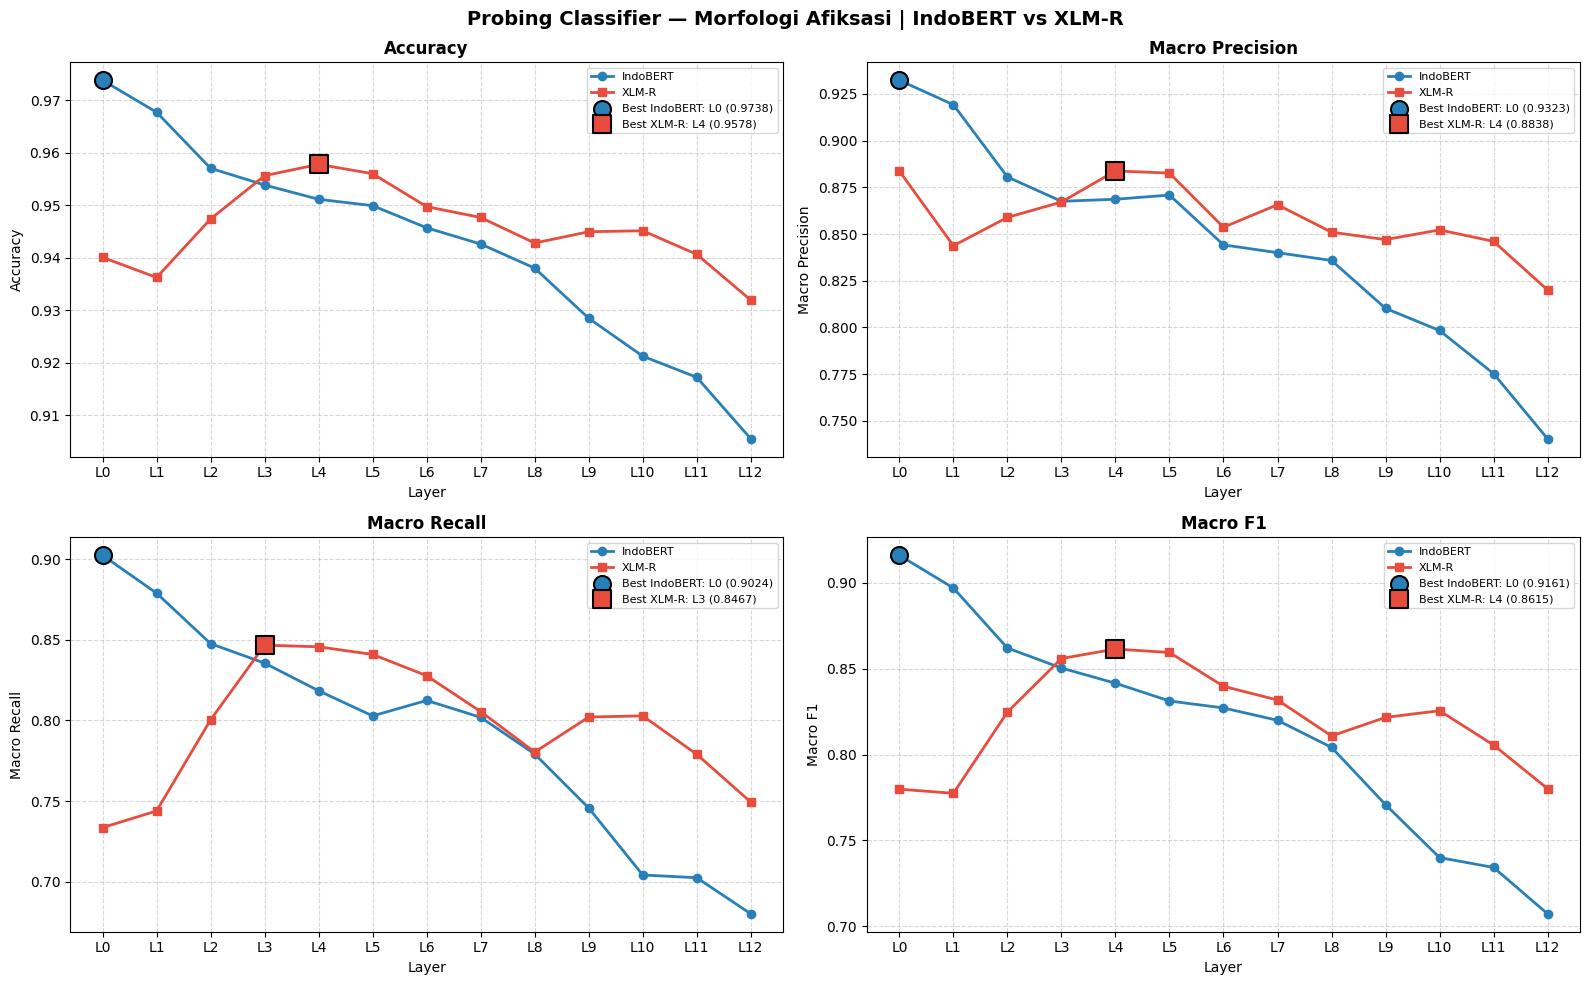

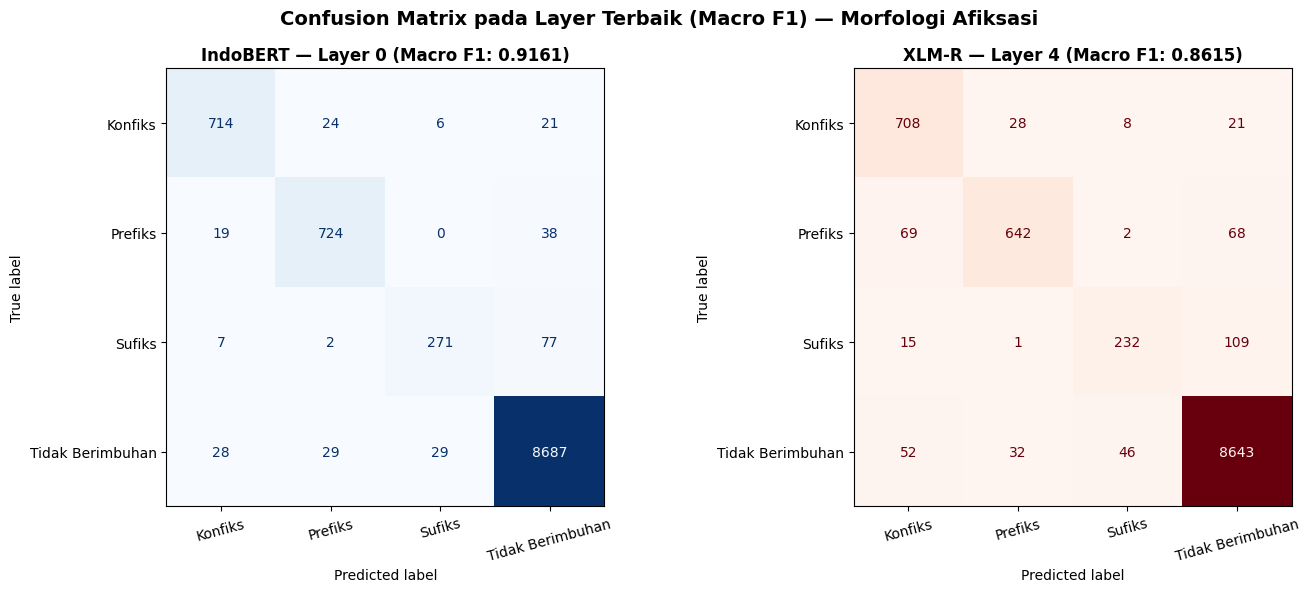


──────────────────────────────────────────────────────────────────────────────────
  RINGKASAN HASIL PROBING CLASSIFIER — MORFOLOGI AFIKSASI
──────────────────────────────────────────────────────────────────────────────────
                    ── IndoBERT ──                          ── XLM-R ──             
Layer        Acc    Prec     Rec     mF1        Acc    Prec     Rec     mF1
──────────────────────────────────────────────────────────────────────────────────
L0        0.9738  0.9323  0.9024  0.9161     0.9401  0.8837  0.7335  0.7799 ✦ best IB
L1        0.9677  0.9192  0.8789  0.8971     0.9362  0.8438  0.7438  0.7775
L2        0.9570  0.8806  0.8476  0.8621     0.9474  0.8589  0.8004  0.8248
L3        0.9538  0.8675  0.8355  0.8504     0.9556  0.8671  0.8467  0.8560
L4        0.9511  0.8686  0.8184  0.8416     0.9578  0.8838  0.8456  0.8615 ✦ best XLM
L5        0.9499  0.8709  0.8028  0.8312     0.9560  0.8826  0.8409  0.8595
L6        0.9457  0.8442  0.8124  0.8272     0.9497  0

In [10]:
# ==========================================================
# TAHAP 6: Training Probing Classifier & Visualisasi 
# ==========================================================

# ── Definisi Probing Classifier ───────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def train_probe(X_train, y_train, X_eval, y_eval,
                hidden_size=768, num_classes=4,
                epochs=10, lr=1e-3, batch_size=64,
                return_preds=False):
    """Melatih probing classifier untuk satu layer. Return (acc, f1, precision, recall) atau +y_pred."""
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_ev = torch.tensor(X_eval,  dtype=torch.float32)
    y_ev = torch.tensor(y_eval,  dtype=torch.long)

    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=batch_size, shuffle=True)
    probe     = LinearProbe(hidden_size, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        probe.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(probe(X_b), y_b).backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        y_pred = probe(X_ev.to(device)).argmax(dim=1).cpu().numpy()

    y_np  = y_ev.numpy()
    acc   = accuracy_score(y_np, y_pred)
    f1    = f1_score(y_np, y_pred, average='macro', zero_division=0) 
    prec  = precision_score(y_np, y_pred, average='macro', zero_division=0) 
    rec   = recall_score(y_np, y_pred, average='macro', zero_division=0) 

    if return_preds:
        return acc, f1, prec, rec, y_pred
    return acc, f1, prec, rec


# ── Training per Layer ────────────────────────────────────────────────────
results = {
    'indobert': {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []}
}

print("\n" + "=" * 85)
print("TRAINING PROBING CLASSIFIER PER LAYER — MORFOLOGI AFIKSASI")
print("=" * 85)
print(f"{'Layer':<7} {'IB Acc':>7} {'IB P':>7} {'IB R':>7} {'IB mF1':>7} │ " 
      f"{'XLM Acc':>7} {'XLM P':>7} {'XLM R':>7} {'XLM mF1':>8}")             
print("-" * 85)

for layer_idx in range(NUM_LAYERS):
    acc_i, f1_i, prec_i, rec_i, pred_i = train_probe(
        X_train_indobert[:, layer_idx, :], y_train,
        X_dev_indobert[:,   layer_idx, :], y_dev,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        return_preds=True
    )
    acc_x, f1_x, prec_x, rec_x, pred_x = train_probe(
        X_train_xlmr[:, layer_idx, :], y_train,
        X_dev_xlmr[:,   layer_idx, :], y_dev,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        return_preds=True
    )

    for key, vals in [
        ('indobert', (acc_i, f1_i, prec_i, rec_i, pred_i)),
        ('xlmr',     (acc_x, f1_x, prec_x, rec_x, pred_x))
    ]:
        results[key]['acc'].append(vals[0])
        results[key]['f1'].append(vals[1])
        results[key]['precision'].append(vals[2])
        results[key]['recall'].append(vals[3])
        results[key]['y_pred'].append(vals[4])

    print(f"L{layer_idx:<6} {acc_i:>7.4f} {prec_i:>7.4f} {rec_i:>7.4f} {f1_i:>7.4f} │ "
          f"{acc_x:>7.4f} {prec_x:>7.4f} {rec_x:>7.4f} {f1_x:>7.4f}")

print("=" * 85)

# ── Indeks layer terbaik ──────────────────────────────────────────────────
best = {
    model: {m: int(np.argmax(results[model][m]))
            for m in ['acc', 'f1', 'precision', 'recall']}
    for model in ['indobert', 'xlmr']
}

# ── Visualisasi Line Plot (Acc, Precision, Recall, Macro F1) ─────────────
layer_ticks  = [f"L{i}" for i in range(NUM_LAYERS)]
metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Macro Precision'),  
    ('recall',    'Macro Recall'),     
    ('f1',        'Macro F1'),          
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Probing Classifier — Morfologi Afiksasi | IndoBERT vs XLM-R',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    b_i = best['indobert'][metric]
    b_x = best['xlmr'][metric]

    ax.plot(layer_ticks, results['indobert'][metric],
            marker='o', linewidth=2, label='IndoBERT', color='#2980b9')
    ax.plot(layer_ticks, results['xlmr'][metric],
            marker='s', linewidth=2, label='XLM-R',    color='#e74c3c')

    ax.scatter(b_i, results['indobert'][metric][b_i],
               s=150, zorder=5, color='#2980b9', edgecolors='black', linewidths=1.5,
               label=f'Best IndoBERT: L{b_i} ({results["indobert"][metric][b_i]:.4f})')
    ax.scatter(b_x, results['xlmr'][metric][b_x],
               s=150, zorder=5, color='#e74c3c', marker='s', edgecolors='black', linewidths=1.5,
               label=f'Best XLM-R: L{b_x} ({results["xlmr"][metric][b_x]:.4f})')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(layer_ticks)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Confusion Matrix pada Layer Terbaik Macro F1 ─────────────────────────
CLASS_NAMES = list(label_encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix pada Layer Terbaik (Macro F1) — Morfologi Afiksasi', 
             fontsize=14, fontweight='bold')

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    b = best[model_key]['f1']
    cm = confusion_matrix(y_dev, results[model_key]['y_pred'][b])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'{model_name} — Layer {b} '
                 f'(Macro F1: {results[model_key]["f1"][b]:.4f})',  
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── Tabel Ringkasan ───────────────────────────────────────────────────────
METRICS = [('acc', 'Acc'), ('precision', 'Prec'), ('recall', 'Rec'), ('f1', 'mF1')]  

# Tandai baris terbaik berdasarkan Macro F1
best_ib_row  = best['indobert']['f1']
best_xlm_row = best['xlmr']['f1']

# Header
col_w = 8
sep   = "─" * (7 + (col_w + 1) * 4 + 3 + (col_w + 1) * 4)
header_metrics = "".join(f"{lbl:>{col_w}}" for _, lbl in METRICS)

print(f"\n{'─' * len(sep)}")
print(f"  RINGKASAN HASIL PROBING CLASSIFIER — MORFOLOGI AFIKSASI")
print(f"{'─' * len(sep)}")
print(f"{'':7}  {'── IndoBERT ──':^{(col_w+1)*4}}   {'── XLM-R ──':^{(col_w+1)*4}}")
print(f"{'Layer':<7} {header_metrics}   {header_metrics}")
print(f"{'─' * len(sep)}")

for i in range(NUM_LAYERS):
    ib_vals  = "".join(f"{results['indobert'][m][i]:>{col_w}.4f}" for m, _ in METRICS)
    xlm_vals = "".join(f"{results['xlmr'][m][i]:>{col_w}.4f}"     for m, _ in METRICS)
    tag = " ✦ best IB"  if i == best_ib_row  else \
          " ✦ best XLM" if i == best_xlm_row else ""
    print(f"L{i:<6} {ib_vals}   {xlm_vals}{tag}")

print(f"{'─' * len(sep)}")

### 7. Analisis Geometris: Center Kernel Alignment (CKA) - Similarity

CKA mengukur kemiripan representasi antar layer / antar model.
<br>Nilai 1.0 = identik | Nilai 0.0 = sama sekali berbeda

Menghitung CKA internal IndoBERT...
Menghitung CKA internal XLM-R...
Menghitung CKA cross-model per layer...


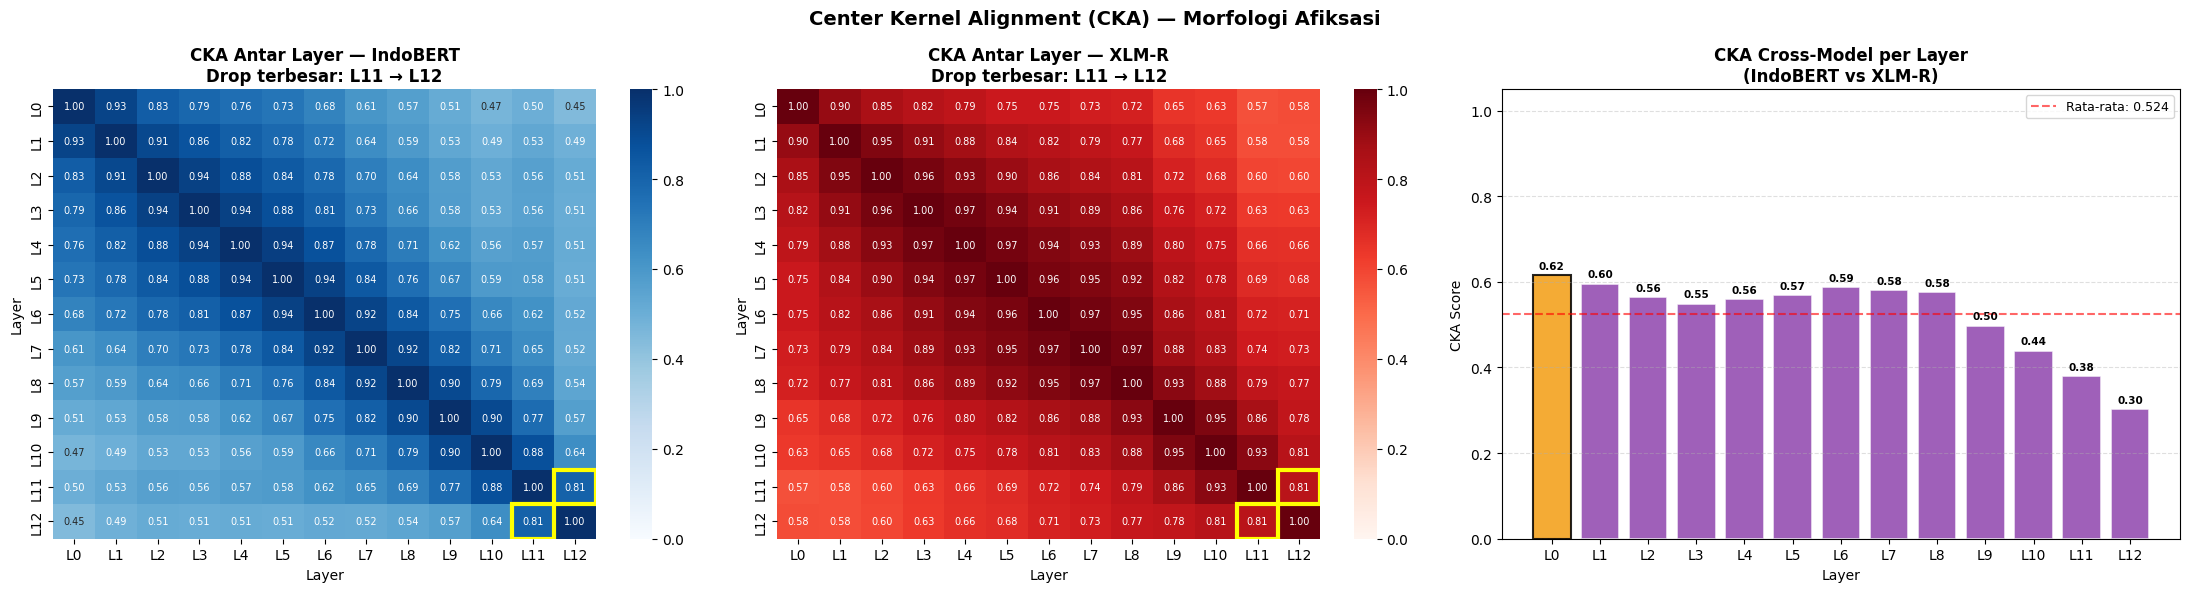

In [11]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA)
# Visual clean + highlight sequential drop terbesar
# ============================================================

# ------------------------------------------------------------
# 1) FUNGSI CKA
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = linear_cka(X_layers[:, i, :], X_layers[:, j, :])
    return M


# ------------------------------------------------------------
# 2) HIGHLIGHT SEQUENTIAL DROP TERBESAR
# ------------------------------------------------------------

def highlight_sequential_max(ax, cka_matrix):
    """
    Highlight pasangan layer berurutan dengan drop terbesar.
    """
    n = cka_matrix.shape[0]

    seq_cka = np.array([cka_matrix[i, i+1] for i in range(n-1)])
    seq_drop = 1 - seq_cka

    best_idx = int(np.argmax(seq_drop))

    # kotak highlight (dua arah karena matriks simetris)
    rect1 = plt.Rectangle((best_idx+1, best_idx), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)
    rect2 = plt.Rectangle((best_idx, best_idx+1), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)

    ax.add_patch(rect1)
    ax.add_patch(rect2)

    return best_idx, seq_cka, seq_drop


# ------------------------------------------------------------
# 3) SAMPLING DATA
# ------------------------------------------------------------

layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

MAX_CKA = 1000
idx_cka = np.random.choice(
    len(X_test_indobert),
    size=min(MAX_CKA, len(X_test_indobert)),
    replace=False
)

X_cka_ib  = X_test_indobert[idx_cka]
X_cka_xlm = X_test_xlmr[idx_cka]


# ------------------------------------------------------------
# 4) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT...")
cka_ib = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R...")
cka_xlm = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])


# ------------------------------------------------------------
# 5) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — Morfologi Afiksasi',
             fontsize=14, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')


# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')


# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_cross,
    color='#8e44ad',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross = int(np.argmax(cka_cross))

bars[best_cross].set_color('#f39c12')
bars[best_cross].set_edgecolor('black')
bars[best_cross].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

## B. POS Tagging (Syntactic)

### 1. Load Dataset dan Encode Label

In [5]:
# ============================================================
# TAHAP 1: LOAD DATASET POS TAGGING
# ============================================================

BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\POS_Tagging"

df_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED, "indolem_train_pos.csv"))
df_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED, "indolem_dev_pos.csv"))
df_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED, "indolem_test_pos.csv"))

COLS_X = ['sent_id', 'token_id', 'token']
COLS_Y = 'pos_tag'

df_train = df_train_raw[COLS_X + [COLS_Y]].dropna().copy()
df_dev   = df_dev_raw[COLS_X + [COLS_Y]].dropna().copy()
df_test  = df_test_raw[COLS_X + [COLS_Y]].dropna().copy()

# Encode label
label_encoder = LabelEncoder()
label_encoder.fit(df_train[COLS_Y])

y_train = label_encoder.transform(df_train[COLS_Y])
y_dev   = label_encoder.transform(df_dev[COLS_Y])
y_test  = label_encoder.transform(df_test[COLS_Y])

df_train['label_encoded'] = y_train
df_dev['label_encoded']   = y_dev
df_test['label_encoded']  = y_test

NUM_CLASSES = len(label_encoder.classes_)
NUM_LAYERS  = 13    # layer-0 (embedding) + layer 1–12 (transformer)
HIDDEN_SIZE = 768

print("=" * 55)
print("INFO DATASET POS TAGGING")
print("=" * 55)
print(f"Kolom X : {COLS_X}")
print(f"Kolom Y : {COLS_Y}")
print(f"Jumlah Kelas : {NUM_CLASSES}")
print(f"Train   : {len(df_train):,} token")
print(f"Dev     : {len(df_dev):,} token")
print(f"Test    : {len(df_test):,} token")

INFO DATASET POS TAGGING
Kolom X : ['sent_id', 'token_id', 'token']
Kolom Y : pos_tag
Jumlah Kelas : 23
Train   : 942,214 token
Dev     : 105,274 token
Test    : 261,872 token


### 2. Ekstraksi Hidden States

Yang dilakukan:
1. Mengekstrak hidden states semua layer untuk setiap token

Input:
1. df: DataFrame dengan kolom [sent_id, token_id, token, pos_tag]
2. tokenizer, model : model HuggingFace yang sudah di-load

Output:
1. np.array shape (total_token, num_layer, hidden_size) | misal: (9232, 13, 768)
2. Layer 0     = embedding statis (non-contextual)
3. Layer 1–12  = transformer layers (contextual)

In [6]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES
# ============================================================

def extract_hidden_states(df, tokenizer, model, device, desc="Ekstraksi"):
    model.eval()
    all_hidden  = []
    all_labels  = []
    skipped_cnt = 0

    # Groupby sent_id, sort token berdasarkan token_id
    grouped = df.groupby('sent_id', sort=False)

    for sent_id, group in tqdm(grouped, desc=desc):
        group  = group.sort_values('token_id')
        tokens = group['token'].tolist()
        labels = group['label_encoded'].tolist()

        # Tokenisasi — is_split_into_words=True karena input sudah list kata
        # Satu kata bisa dipecah jadi beberapa subword oleh tokenizer
        encoding = tokenizer(
            tokens,
            is_split_into_words = True,
            return_tensors      = "pt",
            padding             = True,
            truncation          = True,
            max_length          = 512
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

        hidden_states = outputs.hidden_states

        # ── Mapping subword → token asli ──────────────────────────
        # word_ids() mengembalikan list index kata asli untuk tiap subword
        # Contoh: "membangun" → ["mem", "##bangun"]
        #   word_ids = [None, 0, 0, 0, 1, 1, 2, None]
        #              [CLS] [mem][##b][##u][tok1][tok2] [SEP]
        # Strategi: ambil subword PERTAMA sebagai representasi kata
        word_ids = encoding.word_ids(batch_index=0)

        first_subword_pos = {}
        for pos, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in first_subword_pos:
                first_subword_pos[word_idx] = pos

        for word_idx in range(len(tokens)):
            if word_idx not in first_subword_pos:
                skipped_cnt += 1
                continue

            pos = first_subword_pos[word_idx]

            token_repr = np.array([
                hidden_states[layer_idx][0, pos, :].cpu().numpy()
                for layer_idx in range(len(hidden_states))
            ])

            all_hidden.append(token_repr)
            all_labels.append(labels[word_idx])

    if skipped_cnt > 0:
        print(f"  ⚠ {skipped_cnt} token dilewati akibat truncation (max_length=512)")

    return np.array(all_hidden), np.array(all_labels) 

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States POS Tagging:

In [7]:
SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging"
os.makedirs(SAVE_DIR, exist_ok=True)

Ekstraksi IndoBERT:

In [10]:
# ============================================================
# TAHAP 3: EKSTRAKSI FITUR (INDOBERT) & SIMPAN PER LAYER
# ============================================================

print("=" * 65)
print("EKSTRAKSI HIDDEN STATES — IndoBERT")
print("=" * 65)

# ── 1. Ekstrak & Simpan Dev Set (Per Layer) ──────────────────────────────
print("\n[1/3] Memproses Dev Set...")
X_dev, y_dev = extract_hidden_states(
    df_dev, tokenizer_indobert, model_indobert, device, "IndoBERT | Dev  ")

print("Menyimpan Dev Set per Layer...")
for i in range(NUM_LAYERS):
    # Ambil semua token, HANYA pada layer ke-i, semua hidden size (768)
    X_layer = X_dev[:, i, :].astype(np.float16) 
    np.savez_compressed(os.path.join(SAVE_DIR, f"indobert_pos_dev_L{i}.npz"), X=X_layer, y=y_dev)

del X_dev, y_dev, X_layer
gc.collect() # Bersihkan RAM
print("✅ Dev Set (13 Layer) tersimpan!")


# ── 2. Ekstrak & Simpan Test Set (Per Layer) ──────────────────────────────
print("\n[2/3] Memproses Test Set...")
X_test, y_test = extract_hidden_states(
    df_test, tokenizer_indobert, model_indobert, device, "IndoBERT | Test ")

print("Menyimpan Test Set per Layer...")
for i in range(NUM_LAYERS):
    X_layer = X_test[:, i, :].astype(np.float16)
    np.savez_compressed(os.path.join(SAVE_DIR, f"indobert_pos_test_L{i}.npz"), X=X_layer, y=y_test)

del X_test, y_test, X_layer
gc.collect()
print("✅ Test Set (13 Layer) tersimpan!")


# ── 3. Ekstrak & Simpan Train Set (Chunking + Per Layer) ──────────────────
print("\n[3/3] Memproses Train Set (Dipecah 3 bagian)...")
num_chunks = 3
chunk_size = len(df_train) // num_chunks

for c in range(num_chunks):
    print(f"\n   -> Ekstraksi Train Part {c+1}/{num_chunks}...")
    start_idx = c * chunk_size
    end_idx = len(df_train) if c == num_chunks - 1 else (c + 1) * chunk_size
    
    df_chunk = df_train.iloc[start_idx:end_idx]
    X_chunk, y_chunk = extract_hidden_states(
        df_chunk, tokenizer_indobert, model_indobert, device, f"Train P-{c+1}"
    )
    
    print(f"   -> Menyimpan Train Part {c+1} per Layer...")
    for i in range(NUM_LAYERS):
        X_layer = X_chunk[:, i, :].astype(np.float16)
        np.savez_compressed(os.path.join(SAVE_DIR, f"indobert_pos_train_part{c+1}_L{i}.npz"), X=X_layer, y=y_chunk)
        
    del X_chunk, y_chunk, X_layer
    gc.collect()
    print(f"   ✅ Train Part {c+1} (13 Layer) tersimpan!")

print(f"\n🎉 Selesai! Semua file tersimpan per-layer di: {SAVE_DIR}")

EKSTRAKSI HIDDEN STATES — IndoBERT

[1/3] Memproses Dev Set...


IndoBERT | Dev  : 100%|██████████| 4010/4010 [02:38<00:00, 25.31it/s]


Menyimpan Dev Set per Layer...
✅ Dev Set (13 Layer) tersimpan!

[2/3] Memproses Test Set...


IndoBERT | Test : 100%|██████████| 10030/10030 [06:07<00:00, 27.27it/s]


Menyimpan Test Set per Layer...
✅ Test Set (13 Layer) tersimpan!

[3/3] Memproses Train Set (Dipecah 3 bagian)...

   -> Ekstraksi Train Part 1/3...


...

   -> Menyimpan Train Part 1 per Layer...
   ✅ Train Part 1 (13 Layer) tersimpan!

   -> Ekstraksi Train Part 2/3...


Train P-2: 100%|██████████| 12034/12034 [07:33<00:00, 26.54it/s]


   -> Menyimpan Train Part 2 per Layer...
   ✅ Train Part 2 (13 Layer) tersimpan!

   -> Ekstraksi Train Part 3/3...


Train P-3: 100%|██████████| 12029/12029 [07:19<00:00, 27.35it/s]


   -> Menyimpan Train Part 3 per Layer...
   ✅ Train Part 3 (13 Layer) tersimpan!

🎉 Selesai! Semua file tersimpan per-layer di: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging


### 4. Eksekusi Ekstraksi: XLM-R

In [11]:
# ============================================================
# TAHAP 4: EKSTRAKSI FITUR (XLM-R) & SIMPAN PER LAYER
# ============================================================

print("\n" + "=" * 65)
print("EKSTRAKSI HIDDEN STATES — XLM-R")
print("=" * 65)

# ── 1. Ekstrak & Simpan Dev Set (Per Layer) ──────────────────────────────
print("\n[1/3] Memproses Dev Set (XLM-R)...")
X_dev, y_dev = extract_hidden_states(
    df_dev, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Dev  ")

print("Menyimpan Dev Set XLM-R per Layer...")
for i in range(NUM_LAYERS):
    X_layer = X_dev[:, i, :].astype(np.float16) # Ubah ke float16
    np.savez_compressed(os.path.join(SAVE_DIR, f"xlmr_pos_dev_L{i}.npz"), X=X_layer, y=y_dev)

del X_dev, y_dev, X_layer
gc.collect() # Bersihkan RAM
print("✅ Dev Set XLM-R (13 Layer) tersimpan!")


# ── 2. Ekstrak & Simpan Test Set (Per Layer) ──────────────────────────────
print("\n[2/3] Memproses Test Set (XLM-R)...")
X_test, y_test = extract_hidden_states(
    df_test, tokenizer_xlmr, model_xlmr, device, "XLM-R   | Test ")

print("Menyimpan Test Set XLM-R per Layer...")
for i in range(NUM_LAYERS):
    X_layer = X_test[:, i, :].astype(np.float16)
    np.savez_compressed(os.path.join(SAVE_DIR, f"xlmr_pos_test_L{i}.npz"), X=X_layer, y=y_test)

del X_test, y_test, X_layer
gc.collect()
print("✅ Test Set XLM-R (13 Layer) tersimpan!")


# ── 3. Ekstrak & Simpan Train Set (Chunking + Per Layer) ──────────────────
print("\n[3/3] Memproses Train Set XLM-R (Dipecah 3 bagian)...")
num_chunks = 3
chunk_size = len(df_train) // num_chunks

for c in range(num_chunks):
    print(f"\n   -> Ekstraksi Train Part {c+1}/{num_chunks}...")
    start_idx = c * chunk_size
    end_idx = len(df_train) if c == num_chunks - 1 else (c + 1) * chunk_size
    
    df_chunk = df_train.iloc[start_idx:end_idx]
    X_chunk, y_chunk = extract_hidden_states(
        df_chunk, tokenizer_xlmr, model_xlmr, device, f"Train P-{c+1}"
    )
    
    print(f"   -> Menyimpan Train Part {c+1} XLM-R per Layer...")
    for i in range(NUM_LAYERS):
        X_layer = X_chunk[:, i, :].astype(np.float16)
        np.savez_compressed(os.path.join(SAVE_DIR, f"xlmr_pos_train_part{c+1}_L{i}.npz"), X=X_layer, y=y_chunk)
        
    del X_chunk, y_chunk, X_layer
    gc.collect()
    print(f"   ✅ Train Part {c+1} XLM-R (13 Layer) tersimpan!")

print(f"\n🎉 Selesai! Semua file XLM-R tersimpan per-layer di: {SAVE_DIR}")


EKSTRAKSI HIDDEN STATES — XLM-R

[1/3] Memproses Dev Set (XLM-R)...


XLM-R   | Dev  : 100%|██████████| 4010/4010 [02:32<00:00, 26.36it/s]


Menyimpan Dev Set XLM-R per Layer...
✅ Dev Set XLM-R (13 Layer) tersimpan!

[2/3] Memproses Test Set (XLM-R)...


XLM-R   | Test : 100%|██████████| 10030/10030 [07:19<00:00, 22.80it/s]


Menyimpan Test Set XLM-R per Layer...
✅ Test Set XLM-R (13 Layer) tersimpan!

[3/3] Memproses Train Set XLM-R (Dipecah 3 bagian)...

   -> Ekstraksi Train Part 1/3...


...

   -> Menyimpan Train Part 1 XLM-R per Layer...
   ✅ Train Part 1 XLM-R (13 Layer) tersimpan!

   -> Ekstraksi Train Part 2/3...


Train P-2: 100%|██████████| 12034/12034 [08:38<00:00, 23.19it/s]


   -> Menyimpan Train Part 2 XLM-R per Layer...
   ✅ Train Part 2 XLM-R (13 Layer) tersimpan!

   -> Ekstraksi Train Part 3/3...


Train P-3: 100%|██████████| 12029/12029 [08:41<00:00, 23.08it/s]


   -> Menyimpan Train Part 3 XLM-R per Layer...
   ✅ Train Part 3 XLM-R (13 Layer) tersimpan!

🎉 Selesai! Semua file XLM-R tersimpan per-layer di: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging


### 5. Load Hasil Ekstraksi Hidden States

In [8]:
# ===========================================
# TAHAP 5: LOAD HASIL EKSTRAKSI HIDDEN STATES
# ===========================================

SAVE_DIR = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\POS_Tagging"

print("Memuat Labels (y) dari file...")

# Ambil label y dari salah satu file L0 IndoBERT (karena label y selalu sama untuk L0-L12 dan untuk XLM-R)
tmp_dev = np.load(os.path.join(SAVE_DIR, "indobert_pos_dev_L0.npz"))
y_dev = tmp_dev['y']

tmp_test = np.load(os.path.join(SAVE_DIR, "indobert_pos_test_L0.npz"))
y_test = tmp_test['y']

# Untuk Train, karena kita pecah menjadi 3 part, kita harus menggabungkan labelnya
y_train_parts = []
for c in range(1, 4): # Looping part 1, 2, 3
    tmp_train = np.load(os.path.join(SAVE_DIR, f"indobert_pos_train_part{c}_L0.npz"))
    y_train_parts.append(tmp_train['y'])

y_train = np.concatenate(y_train_parts)

print(f"✅ Label Train : {y_train.shape[0]:,} baris")
print(f"✅ Label Dev   : {y_dev.shape[0]:,} baris")
print(f"✅ Label Test  : {y_test.shape[0]:,} baris")
print("ℹ️ Fitur matriks (X) aman di disk dan akan di-load bergantian per-layer pada Tahap 6.")

Memuat Labels (y) dari file...
✅ Label Train : 942,214 baris
✅ Label Dev   : 105,274 baris
✅ Label Test  : 261,872 baris
ℹ️ Fitur matriks (X) aman di disk dan akan di-load bergantian per-layer pada Tahap 6.


### 6. Training Probing Classifier (Linear Classifier - Single Linear Layer)


TRAINING PROBING CLASSIFIER PER LAYER — POS TAGGING (SINTAKSIS)
Layer    IB Acc    IB P    IB R  IB mF1 │ XLM Acc   XLM P   XLM R  XLM mF1
-------------------------------------------------------------------------------------
L0       0.9318  0.8879  0.8921  0.8861 │  0.9287  0.8822  0.8860   0.8793
L1       0.9392  0.9036  0.9064  0.9043 │  0.9383  0.9132  0.8658   0.8831
L2       0.9527  0.9254  0.9092  0.9162 │  0.9584  0.9321  0.8873   0.9018
L3       0.9532  0.9255  0.9157  0.9201 │  0.9627  0.9302  0.8975   0.9096
L4       0.9555  0.9270  0.9142  0.9197 │  0.9636  0.9259  0.9151   0.9164
L5       0.9539  0.9154  0.9150  0.9142 │  0.9640  0.9031  0.8990   0.9002
L6       0.9557  0.9211  0.9175  0.9184 │  0.9640  0.9095  0.9144   0.9100
L7       0.9520  0.9105  0.9080  0.9076 │  0.9628  0.9235  0.8980   0.9059
L8       0.9493  0.9163  0.9104  0.9126 │  0.9625  0.9040  0.9191   0.9072
L9       0.9467  0.9060  0.8850  0.8913 │  0.9621  0.9110  0.9138   0.9102
L10      0.9419  0.9107 

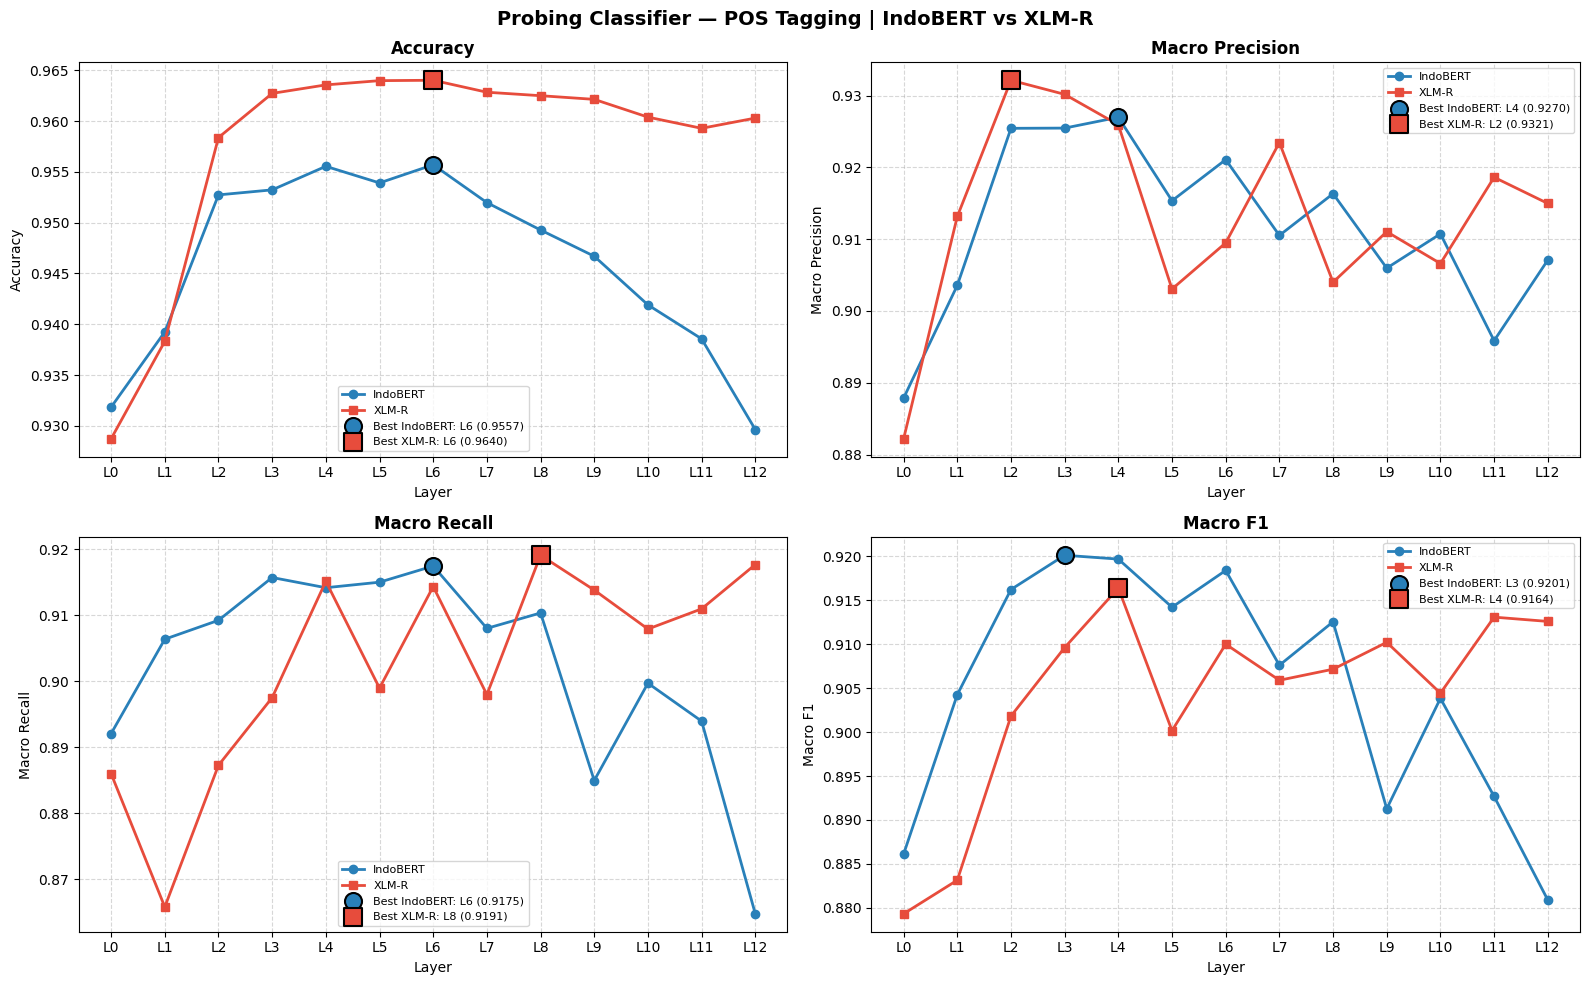

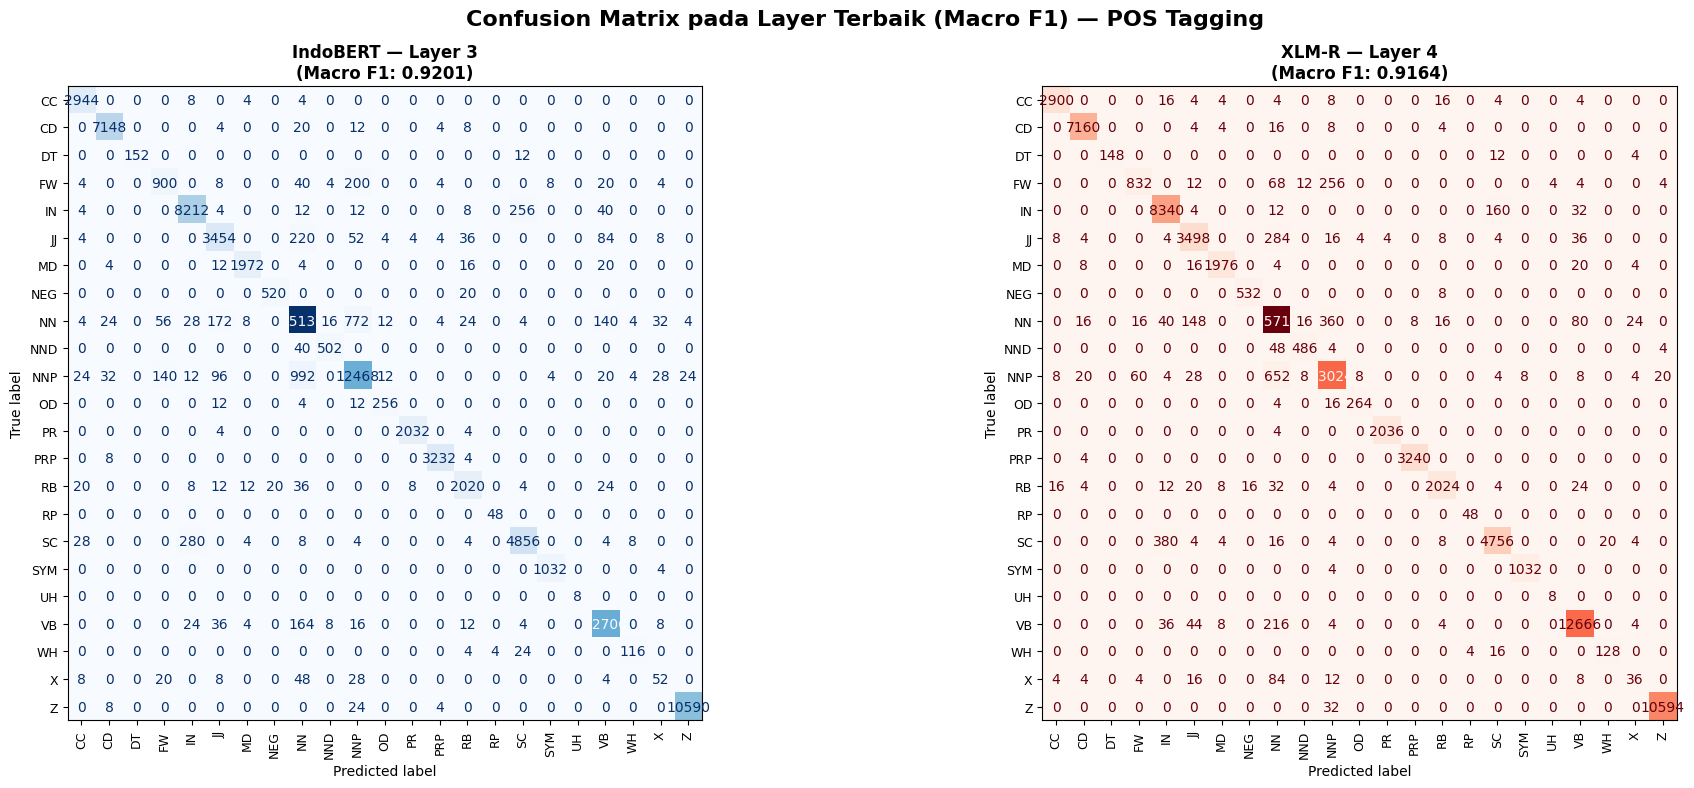


──────────────────────────────────────────────────────────────────────────────────
  RINGKASAN HASIL PROBING CLASSIFIER — POS TAGGING
──────────────────────────────────────────────────────────────────────────────────
                    ── IndoBERT ──                          ── XLM-R ──             
Layer        Acc    Prec     Rec     mF1        Acc    Prec     Rec     mF1
──────────────────────────────────────────────────────────────────────────────────
L0        0.9318  0.8879  0.8921  0.8861     0.9287  0.8822  0.8860  0.8793
L1        0.9392  0.9036  0.9064  0.9043     0.9383  0.9132  0.8658  0.8831
L2        0.9527  0.9254  0.9092  0.9162     0.9584  0.9321  0.8873  0.9018
L3        0.9532  0.9255  0.9157  0.9201     0.9627  0.9302  0.8975  0.9096 ✦ best IB
L4        0.9555  0.9270  0.9142  0.9197     0.9636  0.9259  0.9151  0.9164 ✦ best XLM
L5        0.9539  0.9154  0.9150  0.9142     0.9640  0.9031  0.8990  0.9002
L6        0.9557  0.9211  0.9175  0.9184     0.9640  0.9095  

In [9]:
# ==========================================================
# TAHAP 6: Training Probing Classifier & Visualisasi (POS)
# ==========================================================

# ── Definisi Probing Classifier ───────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

def train_probe(X_train, y_train, X_eval, y_eval,
                hidden_size=768, num_classes=23,
                epochs=10, lr=1e-3, batch_size=64,
                return_preds=False):
    """Melatih probing classifier untuk satu layer. Return metrics & predictions."""
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_ev = torch.tensor(X_eval,  dtype=torch.float32)
    y_ev = torch.tensor(y_eval,  dtype=torch.long)

    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=batch_size, shuffle=True)
    probe     = LinearProbe(hidden_size, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        probe.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(probe(X_b), y_b).backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        y_pred = probe(X_ev.to(device)).argmax(dim=1).cpu().numpy()

    y_np  = y_ev.numpy()
    acc   = accuracy_score(y_np, y_pred)
    f1    = f1_score(y_np, y_pred, average='macro', zero_division=0)
    prec  = precision_score(y_np, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_np, y_pred, average='macro', zero_division=0)

    if return_preds:
        return acc, f1, prec, rec, y_pred
    return acc, f1, prec, rec

# ── Fungsi Load-on-the-fly  ────────────────────────────────────
def load_layer_X(model_prefix, layer_idx, num_chunks=3):
    """Meload fitur X hanya untuk layer yang sedang diproses."""
    # Load Dev
    tmp_dev = np.load(os.path.join(SAVE_DIR, f"{model_prefix}_pos_dev_L{layer_idx}.npz"))
    X_dev_layer = tmp_dev['X']

    # Load Train (Gabungan 3 part)
    X_train_parts = []
    for c in range(1, num_chunks + 1):
        tmp_train = np.load(os.path.join(SAVE_DIR, f"{model_prefix}_pos_train_part{c}_L{layer_idx}.npz"))
        X_train_parts.append(tmp_train['X'])

    X_train_layer = np.vstack(X_train_parts)
    return X_train_layer, X_dev_layer

# ── Training per Layer ────────────────────────────────────────────────────
results_pos = {
    'indobert': {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []}
}

print("\n" + "=" * 85)
print("TRAINING PROBING CLASSIFIER PER LAYER — POS TAGGING (SINTAKSIS)")
print("=" * 85)
print(f"{'Layer':<7} {'IB Acc':>7} {'IB P':>7} {'IB R':>7} {'IB mF1':>7} │ "
      f"{'XLM Acc':>7} {'XLM P':>7} {'XLM R':>7} {'XLM mF1':>8}")
print("-" * 85)

for layer_idx in range(NUM_LAYERS):
    # 1. Eksekusi IndoBERT
    X_train_ib, X_dev_ib = load_layer_X("indobert", layer_idx)
    acc_i, f1_i, prec_i, rec_i, pred_i = train_probe(
        X_train_ib, y_train, X_dev_ib, y_dev,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        return_preds=True
    )
    del X_train_ib, X_dev_ib
    gc.collect()

    # 2. Eksekusi XLM-R
    X_train_xlm, X_dev_xlm = load_layer_X("xlmr", layer_idx)
    acc_x, f1_x, prec_x, rec_x, pred_x = train_probe(
        X_train_xlm, y_train, X_dev_xlm, y_dev,
        hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES,
        return_preds=True
    )
    del X_train_xlm, X_dev_xlm
    gc.collect()

    # 3. Simpan metrik
    for key, vals in [
        ('indobert', (acc_i, f1_i, prec_i, rec_i, pred_i)),
        ('xlmr',     (acc_x, f1_x, prec_x, rec_x, pred_x))
    ]:
        results_pos[key]['acc'].append(vals[0])
        results_pos[key]['f1'].append(vals[1])
        results_pos[key]['precision'].append(vals[2])
        results_pos[key]['recall'].append(vals[3])
        results_pos[key]['y_pred'].append(vals[4])

    print(f"L{layer_idx:<6} {acc_i:>7.4f} {prec_i:>7.4f} {rec_i:>7.4f} {f1_i:>7.4f} │ "
          f"{acc_x:>7.4f} {prec_x:>7.4f} {rec_x:>7.4f} {f1_x:>8.4f}")

print("=" * 85)

# ── Indeks layer terbaik ──────────────────────────────────────────────────
best_pos = {
    model: {m: int(np.argmax(results_pos[model][m]))
            for m in ['acc', 'f1', 'precision', 'recall']}
    for model in ['indobert', 'xlmr']
}

# ── Visualisasi Line Plot (Acc, Macro Precision, Macro Recall, Macro F1) ──
layer_ticks  = [f"L{i}" for i in range(NUM_LAYERS)]
metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Macro Precision'),
    ('recall',    'Macro Recall'),
    ('f1',        'Macro F1'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Probing Classifier — POS Tagging | IndoBERT vs XLM-R',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    b_i = best_pos['indobert'][metric]
    b_x = best_pos['xlmr'][metric]

    ax.plot(layer_ticks, results_pos['indobert'][metric],
            marker='o', linewidth=2, label='IndoBERT', color='#2980b9')
    ax.plot(layer_ticks, results_pos['xlmr'][metric],
            marker='s', linewidth=2, label='XLM-R',    color='#e74c3c')

    ax.scatter(b_i, results_pos['indobert'][metric][b_i],
               s=150, zorder=5, color='#2980b9', edgecolors='black', linewidths=1.5,
               label=f'Best IndoBERT: L{b_i} ({results_pos["indobert"][metric][b_i]:.4f})')
    ax.scatter(b_x, results_pos['xlmr'][metric][b_x],
               s=150, zorder=5, color='#e74c3c', marker='s', edgecolors='black', linewidths=1.5,
               label=f'Best XLM-R: L{b_x} ({results_pos["xlmr"][metric][b_x]:.4f})')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(layer_ticks)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Confusion Matrix pada Layer Terbaik Macro F1 ─────────────────────────
CLASS_NAMES = list(label_encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Confusion Matrix pada Layer Terbaik (Macro F1) — POS Tagging',
             fontsize=16, fontweight='bold')

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    b  = best_pos[model_key]['f1']
    cm = confusion_matrix(y_dev, results_pos[model_key]['y_pred'][b])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=color, xticks_rotation=90)
    ax.set_title(f'{model_name} — Layer {b}\n'
                 f'(Macro F1: {results_pos[model_key]["f1"][b]:.4f})',
                 fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()

# ── Tabel Ringkasan ───────────────────────────────────────────────────────
METRICS = [('acc', 'Acc'), ('precision', 'Prec'), ('recall', 'Rec'), ('f1', 'mF1')]

best_ib_row  = best_pos['indobert']['f1']
best_xlm_row = best_pos['xlmr']['f1']

col_w          = 8
sep            = "─" * (7 + (col_w + 1) * 4 + 3 + (col_w + 1) * 4)
header_metrics = "".join(f"{lbl:>{col_w}}" for _, lbl in METRICS)

print(f"\n{'─' * len(sep)}")
print(f"  RINGKASAN HASIL PROBING CLASSIFIER — POS TAGGING")
print(f"{'─' * len(sep)}")
print(f"{'':7}  {'── IndoBERT ──':^{(col_w+1)*4}}   {'── XLM-R ──':^{(col_w+1)*4}}")
print(f"{'Layer':<7} {header_metrics}   {header_metrics}")
print(f"{'─' * len(sep)}")

for i in range(NUM_LAYERS):
    ib_vals  = "".join(f"{results_pos['indobert'][m][i]:>{col_w}.4f}" for m, _ in METRICS)
    xlm_vals = "".join(f"{results_pos['xlmr'][m][i]:>{col_w}.4f}"     for m, _ in METRICS)
    tag = " ✦ best IB"  if i == best_ib_row  else \
          " ✦ best XLM" if i == best_xlm_row else ""
    print(f"L{i:<6} {ib_vals}   {xlm_vals}{tag}")

print(f"{'─' * len(sep)}")


### 7. Analisis Geometris: Center Kernel Alignment (CKA) - Similarity (POS Tagging)

Memuat sebagian data Test (Sampling) dari disk untuk CKA...
✅ Data CKA siap dengan shape: (1000, 13, 768)
Menghitung CKA internal IndoBERT (POS Tagging)...
Menghitung CKA internal XLM-R (POS Tagging)...
Menghitung CKA cross-model per layer...


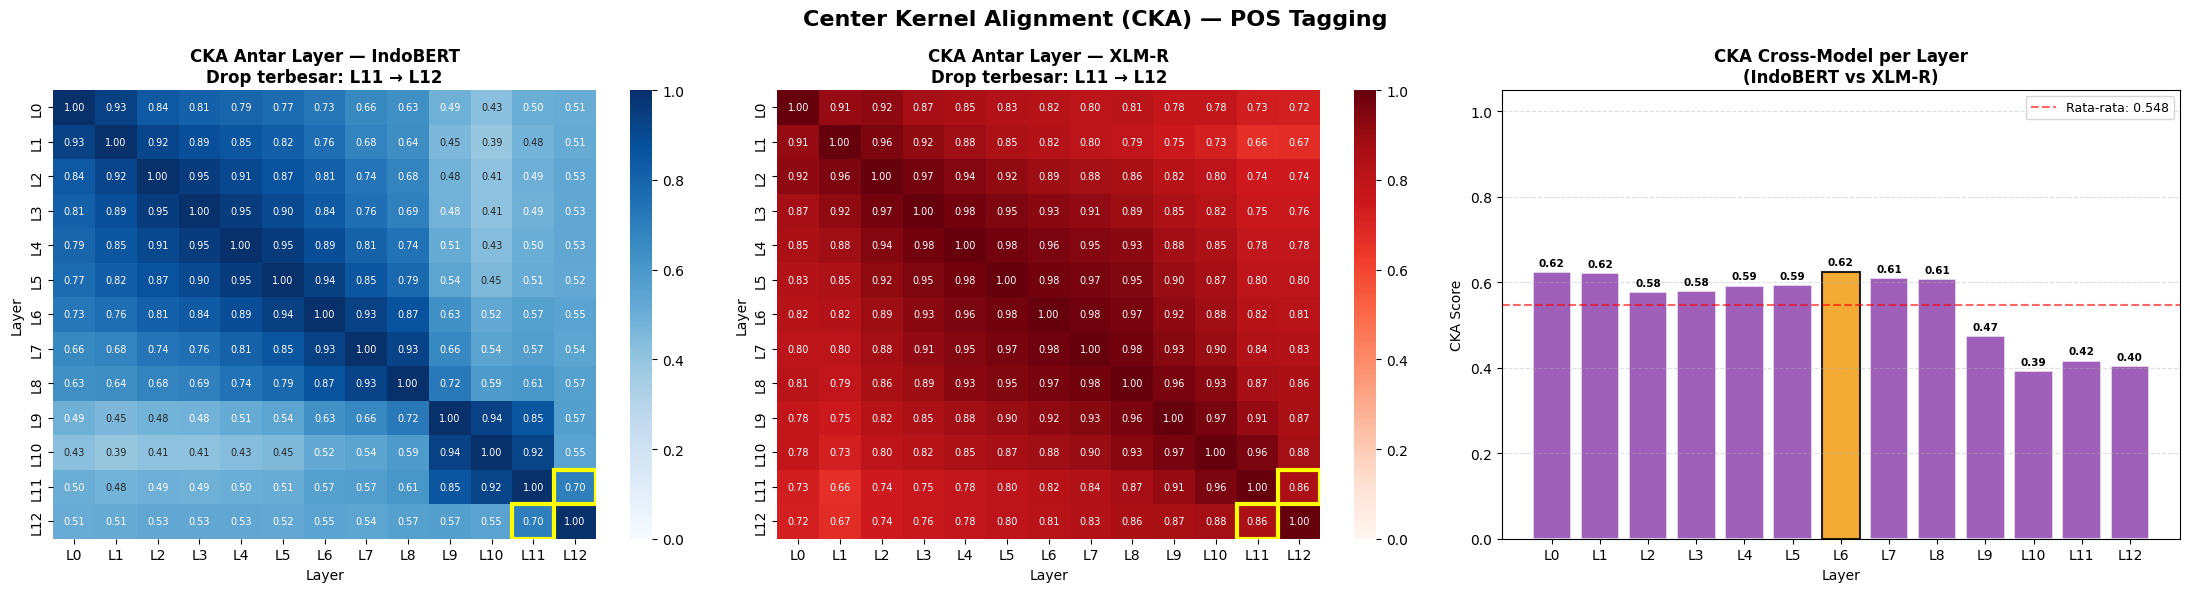

In [10]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA) - POS TAGGING
# ============================================================

# ------------------------------------------------------------
# 1) FUNGSI CKA
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = linear_cka(X_layers[:, i, :], X_layers[:, j, :])
    return M

# ------------------------------------------------------------
# 2) HIGHLIGHT SEQUENTIAL DROP TERBESAR
# ------------------------------------------------------------

def highlight_sequential_max(ax, cka_matrix):
    """
    Highlight pasangan layer berurutan dengan drop terbesar.
    """
    n = cka_matrix.shape[0]
    seq_cka = np.array([cka_matrix[i, i+1] for i in range(n-1)])
    seq_drop = 1 - seq_cka
    best_idx = int(np.argmax(seq_drop))

    # kotak highlight (dua arah karena matriks simetris)
    rect1 = plt.Rectangle((best_idx+1, best_idx), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)
    rect2 = plt.Rectangle((best_idx, best_idx+1), 1, 1,
                          fill=False, edgecolor='yellow', linewidth=3)

    ax.add_patch(rect1)
    ax.add_patch(rect2)
    return best_idx, seq_cka, seq_drop

# ------------------------------------------------------------
# 3) SAMPLING DATA (Load-on-the-fly untuk Hemat RAM)
# ------------------------------------------------------------
layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]

MAX_CKA = 1000
total_test_samples = len(y_test) # Memanfaatkan y_test dari Tahap 5 yang masih di RAM

np.random.seed(42) # Agar index random yang dipilih selalu konsisten
idx_cka = np.random.choice(
    total_test_samples,
    size=min(MAX_CKA, total_test_samples),
    replace=False
)

# Siapkan matriks kosong dengan presisi float16 agar sangat ringan
X_cka_ib  = np.zeros((len(idx_cka), NUM_LAYERS, HIDDEN_SIZE), dtype=np.float16)
X_cka_xlm = np.zeros((len(idx_cka), NUM_LAYERS, HIDDEN_SIZE), dtype=np.float16)

print("Memuat sebagian data Test (Sampling) dari disk untuk CKA...")

for i in range(NUM_LAYERS):
    # Load spesifik layer i untuk IndoBERT
    tmp_ib = np.load(os.path.join(SAVE_DIR, f"indobert_pos_test_L{i}.npz"))
    X_cka_ib[:, i, :] = tmp_ib['X'][idx_cka]  # Hanya ambil baris sesuai idx_cka
    
    # Load spesifik layer i untuk XLM-R
    tmp_xlm = np.load(os.path.join(SAVE_DIR, f"xlmr_pos_test_L{i}.npz"))
    X_cka_xlm[:, i, :] = tmp_xlm['X'][idx_cka]
    
    del tmp_ib, tmp_xlm # Hapus dari RAM
    gc.collect()

print(f"✅ Data CKA siap dengan shape: {X_cka_ib.shape}")

# ------------------------------------------------------------
# 4) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT (POS Tagging)...")
cka_ib = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R (POS Tagging)...")
cka_xlm = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])

# ------------------------------------------------------------
# 5) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — POS Tagging',
             fontsize=16, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')

# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')

# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_cross,
    color='#8e44ad',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross = int(np.argmax(cka_cross))

bars[best_cross].set_color('#f39c12')
bars[best_cross].set_edgecolor('black')
bars[best_cross].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

## C. Relasi Sintaksis (Syntactic) - *Dependency Label Classification*

### 1. Load Dataset dan Encode Label

Kolom yang digunakan:
<br>`sent_id`, `token_id`, `token` → untuk ekstraksi representasi & grouping
<br>`head` → token_id kepala (untuk membangun pasangan)
<br>`deprel` → label relasi sintaksis (Y)
 
Dua DataFrame disiapkan:
- `df_dep_*` → token **non-root** saja (yang menjadi dependent dalam pasangan)
- `df_dep_*_full` → **semua token** termasuk root (dipakai untuk lookup vektor head)
 
**Kenapa perlu `df_full`?** Token root (head=0) dihapus dari `df_dep` karena dia
tidak punya head di luar dirinya sendiri. Namun, token lain bisa saja ber-head
ke token root. Jika root tidak ada di lookup, maka semua token yang menunjuk ke root akan diskip — inilah penyebab skip massal sebelumnya.

In [5]:
# ============================================================
# TAHAP 1: LOAD DATASET DEPENDENCY LABEL CLASSIFICATION
# ============================================================
 
BASE_PROCESSED_DEP = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Relasi_Sintaksis"
 
COLS_KEEP_DEP = ['sent_id', 'token_id', 'token', 'head', 'deprel']
 
df_dep_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED_DEP, "ud-indo-gsd_train_syntactic.csv"))
df_dep_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED_DEP, "ud-indo-gsd_dev_syntactic.csv"))
df_dep_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED_DEP, "ud-indo-gsd_test_syntactic.csv"))
 
# ── df_full: semua token termasuk root → untuk lookup vektor head ─────────
df_dep_train_full = df_dep_train_raw[COLS_KEEP_DEP].copy()
df_dep_dev_full   = df_dep_dev_raw  [COLS_KEEP_DEP].copy()
df_dep_test_full  = df_dep_test_raw [COLS_KEEP_DEP].copy()
 
# ── df_dep: hanya token non-root → yang dijadikan pasangan (dep, head) ────
# Token root (head==0) tidak punya head di luar dirinya, jadi tidak bisa
# dibentuk pasangan (dep, head) yang valid. Namun df_full tetap menyimpannya
# agar bisa dipakai sebagai head oleh token lain.
df_dep_train = df_dep_train_full[df_dep_train_full['head'] != 0].reset_index(drop=True)
df_dep_dev   = df_dep_dev_full  [df_dep_dev_full  ['head'] != 0].reset_index(drop=True)
df_dep_test  = df_dep_test_full [df_dep_test_full ['head'] != 0].reset_index(drop=True)
 
# ── Encode label deprel ───────────────────────────────────────────────────
dep_label_encoder = LabelEncoder()
dep_label_encoder.fit(df_dep_train['deprel'])
 
df_dep_train['label_encoded'] = dep_label_encoder.transform(df_dep_train['deprel'])
df_dep_dev  ['label_encoded'] = dep_label_encoder.transform(df_dep_dev  ['deprel'])
df_dep_test ['label_encoded'] = dep_label_encoder.transform(df_dep_test ['deprel'])
 
DEP_NUM_CLASSES = len(dep_label_encoder.classes_)
NUM_LAYERS      = 13
HIDDEN_SIZE     = 768
 
print("=" * 60)
print("INFO DATASET DEPENDENCY LABEL CLASSIFICATION")
print("=" * 60)
print(f"Kolom X      : ['sent_id', 'token_id', 'token', 'head']")
print(f"Kolom Y      : deprel")
print(f"Jumlah kelas : {DEP_NUM_CLASSES}")
print(f"Kelas deprel : {list(dep_label_encoder.classes_)}")
print(f"Train (non-root) : {len(df_dep_train):,} pasangan")
print(f"Dev   (non-root) : {len(df_dep_dev):,} pasangan")
print(f"Test  (non-root) : {len(df_dep_test):,} pasangan")
print(f"\nTrain (full incl. root) : {len(df_dep_train_full):,} token")
print(f"Dev   (full incl. root) : {len(df_dep_dev_full):,} token")
print(f"Test  (full incl. root) : {len(df_dep_test_full):,} token")

INFO DATASET DEPENDENCY LABEL CLASSIFICATION
Kolom X      : ['sent_id', 'token_id', 'token', 'head']
Kolom Y      : deprel
Jumlah kelas : 30
Kelas deprel : ['acl', 'advcl', 'advmod', 'amod', 'appos', 'aux', 'case', 'cc', 'ccomp', 'compound', 'compound:plur', 'conj', 'cop', 'csubj', 'csubj:pass', 'dep', 'det', 'fixed', 'flat', 'iobj', 'mark', 'nmod', 'nsubj', 'nsubj:pass', 'nummod', 'obj', 'obl', 'parataxis', 'punct', 'xcomp']
Train (non-root) : 93,054 pasangan
Dev   (non-root) : 12,053 pasangan
Test  (non-root) : 11,223 pasangan

Train (full incl. root) : 97,531 token
Dev   (full incl. root) : 12,612 token
Test  (full incl. root) : 11,780 token


### 2. Ekstraksi Hidden States

Berbeda dengan Morfologi/POS/Negasi yang mengekstrak **1 vektor per token**,
dependency mengekstrak **pasangan (vektor_dependent, vektor_head)** per relasi.
 
Kenapa pasangan? Karena label deprel mendeskripsikan **HUBUNGAN** antara 2 token,
bukan properti 1 token secara mandiri.
<br>Contoh: `"yang"` → `[nsubj:pass]` → `"terletak"`
 
Output:
<br>- `all_dep`  : `(N_pairs, 13, 768)` → hidden states token dependent
<br>- `all_head` : `(N_pairs, 13, 768)` → hidden states token head
<br>- `all_y`    : `(N_pairs,)`         → label deprel encoded

In [6]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES — DEPENDENCY
# ============================================================
 
def extract_hidden_states_dep(df, df_full, tokenizer, model, device, desc="Ekstraksi"):
    """
    Mengekstrak hidden states pasangan (dependent, head) untuk dependency probing.
 
    Parameter:
        df      : DataFrame non-root (head != 0) — berisi pasangan yang akan diproses
        df_full : DataFrame lengkap (termasuk root) — untuk lookup posisi token head
 
    Mengapa df_full diperlukan?
        Token root (head=0) dibuang dari df agar tidak membentuk pasangan kosong,
        namun token lain BISA memiliki head yang berupa token root.
        Tanpa df_full, semua token yang menunjuk ke root akan diskip karena
        token root tidak ada dalam lookup.
 
    Output:
        all_dep  : (N_pairs, num_layers, hidden_size) = (N, 13, 768)
        all_head : (N_pairs, num_layers, hidden_size) = (N, 13, 768)
        all_y    : (N_pairs,)
    """
    model.eval()
    all_dep      = []
    all_head_vec = []
    all_y        = []
    skipped_cnt  = 0
 
    # ── Pra-hitung lookup per kalimat dari df_full ────────────────────────
    # Dilakukan sekali di luar loop utama agar efisien
    # sent_id → list token (urutan asli kalimat, 0-based)
    # sent_id → {token_id (1-based UD) : word_index (0-based)}
    sent_tokens         = {}
    sent_tokenid_to_idx = {}
 
    for sid, grp in df_full.groupby('sent_id', sort=False):
        grp = grp.sort_values('token_id').reset_index(drop=True)
        sent_tokens[sid] = grp['token'].tolist()
        sent_tokenid_to_idx[sid] = {
            int(row['token_id']): idx
            for idx, (_, row) in enumerate(grp.iterrows())
        }
 
    # ── Loop utama: per kalimat dari df (non-root) ────────────────────────
    grouped = df.groupby('sent_id', sort=False)
 
    for sent_id, group in tqdm(grouped, desc=desc):
        group = group.sort_values('token_id').reset_index(drop=True)
 
        # Gunakan token list LENGKAP (dari df_full) untuk tokenisasi
        # Penting: tokenizer harus melihat kalimat utuh agar word_ids konsisten
        tokens         = sent_tokens.get(sent_id, [])
        tokenid_to_idx = sent_tokenid_to_idx.get(sent_id, {})
 
        if not tokens:
            skipped_cnt += len(group)
            continue
 
        # Tokenisasi kalimat lengkap
        encoding = tokenizer(
            tokens,
            is_split_into_words = True,
            return_tensors      = "pt",
            padding             = True,
            truncation          = True,
            max_length          = 512
        )
 
        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
 
        with torch.no_grad():
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )
 
        # hidden_states: tuple (13,) masing-masing shape (1, seq_len, 768)
        hidden_states = outputs.hidden_states
 
        # Mapping subword → posisi subword pertama tiap kata (strategi first-subword)
        # word_ids() mengembalikan index kata asli (0-based) untuk tiap subword
        word_ids = encoding.word_ids(batch_index=0)
        first_subword_pos = {}
        for pos, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in first_subword_pos:
                first_subword_pos[word_idx] = pos
 
        # ── Bangun pasangan (dep, head) per token dalam kalimat ───────────
        for _, row in group.iterrows():
            dep_tokenid  = int(row['token_id'])   # 1-based (UD format)
            head_tokenid = int(row['head'])        # 1-based (UD format)
            label        = row['label_encoded']
 
            # Konversi token_id (1-based) → word_index (0-based)
            dep_idx  = tokenid_to_idx.get(dep_tokenid,  None)
            head_idx = tokenid_to_idx.get(head_tokenid, None)
 
            # Skip jika token dependent tidak ditemukan / terpotong truncation
            if dep_idx is None or dep_idx not in first_subword_pos:
                skipped_cnt += 1
                continue
 
            # Skip jika token head tidak ditemukan / terpotong truncation
            if head_idx is None or head_idx not in first_subword_pos:
                skipped_cnt += 1
                continue
 
            pos_dep  = first_subword_pos[dep_idx]
            pos_head = first_subword_pos[head_idx]
 
            # Ekstrak vektor semua layer untuk token dependent
            # shape: (num_layers, hidden_size) = (13, 768)
            repr_dep = np.array([
                hidden_states[l][0, pos_dep,  :].cpu().numpy()
                for l in range(len(hidden_states))
            ])
 
            # Ekstrak vektor semua layer untuk token head
            repr_head = np.array([
                hidden_states[l][0, pos_head, :].cpu().numpy()
                for l in range(len(hidden_states))
            ])
 
            all_dep.append(repr_dep)
            all_head_vec.append(repr_head)
            all_y.append(label)
 
    if skipped_cnt > 0:
        print(f"  ⚠ {skipped_cnt} pasangan dilewati "
              f"(truncation / token tidak ditemukan)")
 
    return (
        np.array(all_dep),        # (N_pairs, 13, 768)
        np.array(all_head_vec),   # (N_pairs, 13, 768)
        np.array(all_y)           # (N_pairs,)
    )

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States Dependency Parsing:

In [7]:
SAVE_DIR_DEP = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Relasi_Sintaksis"
os.makedirs(SAVE_DIR_DEP, exist_ok=True)

Ekstraksi IndoBERT:

In [43]:
# ============================================================
# TAHAP 3: EKSTRAKSI & SIMPAN KE DISK — DEPENDENCY (INDOBERT)
# ============================================================
# ⚠ Jalankan SEKALI saja.
#   Setelah file .npz tersimpan, langsung lompat ke Tahap 5.
# ============================================================
 
print("=" * 60)
print("EKSTRAKSI HIDDEN STATES DEPENDENCY — IndoBERT")
print("=" * 60)
 
X_dep_tr_ib, X_head_tr_ib, y_dep_tr = extract_hidden_states_dep(
    df_dep_train, df_dep_train_full,
    tokenizer_indobert, model_indobert, device, "IndoBERT | Train")
 
X_dep_dv_ib, X_head_dv_ib, y_dep_dv = extract_hidden_states_dep(
    df_dep_dev, df_dep_dev_full,
    tokenizer_indobert, model_indobert, device, "IndoBERT | Dev  ")
 
X_dep_ts_ib, X_head_ts_ib, y_dep_ts = extract_hidden_states_dep(
    df_dep_test, df_dep_test_full,
    tokenizer_indobert, model_indobert, device, "IndoBERT | Test ")
 
print(f"\nShape dep  → Train: {X_dep_tr_ib.shape} | "
      f"Dev: {X_dep_dv_ib.shape} | Test: {X_dep_ts_ib.shape}")
print(f"Shape head → Train: {X_head_tr_ib.shape} | "
      f"Dev: {X_head_dv_ib.shape} | Test: {X_head_ts_ib.shape}")
 
print("\nMenyimpan IndoBERT ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR_DEP, "indobert_dep.npz"),
    dep_train  = X_dep_tr_ib,    head_train  = X_head_tr_ib,   y_train = y_dep_tr,
    dep_dev    = X_dep_dv_ib,    head_dev    = X_head_dv_ib,   y_dev   = y_dep_dv,
    dep_test   = X_dep_ts_ib,    head_test   = X_head_ts_ib,   y_test  = y_dep_ts,
)
print(f"✅ Tersimpan → indobert_dep.npz")
print(f"   Lokasi: {SAVE_DIR_DEP}")
 
del X_dep_tr_ib, X_head_tr_ib
del X_dep_dv_ib, X_head_dv_ib
del X_dep_ts_ib, X_head_ts_ib
gc.collect()

EKSTRAKSI HIDDEN STATES DEPENDENCY — IndoBERT


IndoBERT | Train: 100%|██████████| 4477/4477 [04:14<00:00, 17.58it/s]


  ⚠ 2 pasangan dilewati (truncation / token tidak ditemukan)


IndoBERT | Dev  : 100%|██████████| 559/559 [00:37<00:00, 14.83it/s]
IndoBERT | Test : 100%|██████████| 557/557 [00:35<00:00, 15.61it/s]



Shape dep  → Train: (93052, 13, 768) | Dev: (12053, 13, 768) | Test: (11223, 13, 768)
Shape head → Train: (93052, 13, 768) | Dev: (12053, 13, 768) | Test: (11223, 13, 768)

Menyimpan IndoBERT ke disk...
✅ Tersimpan → indobert_dep.npz
   Lokasi: D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Relasi_Sintaksis


0

### 4. Eksekusi Ekstraksi: XLM-R

In [44]:
# ============================================================
# TAHAP 4: EKSTRAKSI & SIMPAN KE DISK — DEPENDENCY (XLM-R)
# ============================================================
# ⚠ Jalankan SEKALI saja.
# ============================================================
 
print("\n" + "=" * 60)
print("EKSTRAKSI HIDDEN STATES DEPENDENCY — XLM-R")
print("=" * 60)
 
X_dep_tr_xlm, X_head_tr_xlm, _ = extract_hidden_states_dep(
    df_dep_train, df_dep_train_full,
    tokenizer_xlmr, model_xlmr, device, "XLM-R   | Train")
 
X_dep_dv_xlm, X_head_dv_xlm, _ = extract_hidden_states_dep(
    df_dep_dev, df_dep_dev_full,
    tokenizer_xlmr, model_xlmr, device, "XLM-R   | Dev  ")
 
X_dep_ts_xlm, X_head_ts_xlm, _ = extract_hidden_states_dep(
    df_dep_test, df_dep_test_full,
    tokenizer_xlmr, model_xlmr, device, "XLM-R   | Test ")
 
print(f"\nShape dep  → Train: {X_dep_tr_xlm.shape} | "
      f"Dev: {X_dep_dv_xlm.shape} | Test: {X_dep_ts_xlm.shape}")
 
print("\nMenyimpan XLM-R ke disk...")
np.savez_compressed(
    os.path.join(SAVE_DIR_DEP, "xlmr_dep.npz"),
    dep_train  = X_dep_tr_xlm,   head_train  = X_head_tr_xlm,  y_train = y_dep_tr,
    dep_dev    = X_dep_dv_xlm,   head_dev    = X_head_dv_xlm,  y_dev   = y_dep_dv,
    dep_test   = X_dep_ts_xlm,   head_test   = X_head_ts_xlm,  y_test  = y_dep_ts,
)
print(f"✅ Tersimpan → xlmr_dep.npz")
 
del X_dep_tr_xlm, X_head_tr_xlm
del X_dep_dv_xlm, X_head_dv_xlm
del X_dep_ts_xlm, X_head_ts_xlm
gc.collect()
 
print("\n✅ Semua hidden states dependency berhasil disimpan ke disk!")


EKSTRAKSI HIDDEN STATES DEPENDENCY — XLM-R


XLM-R   | Train: 100%|██████████| 4477/4477 [04:51<00:00, 15.36it/s]


  ⚠ 2 pasangan dilewati (truncation / token tidak ditemukan)


XLM-R   | Dev  : 100%|██████████| 559/559 [00:38<00:00, 14.36it/s]
XLM-R   | Test : 100%|██████████| 557/557 [00:32<00:00, 17.11it/s]



Shape dep  → Train: (93052, 13, 768) | Dev: (12053, 13, 768) | Test: (11223, 13, 768)

Menyimpan XLM-R ke disk...
✅ Tersimpan → xlmr_dep.npz

✅ Semua hidden states dependency berhasil disimpan ke disk!


### 5. Load Hasil Ekstraksi Hidden States

In [8]:
# ============================================================
# TAHAP 5: LOAD DARI DISK
# ============================================================
 
SAVE_DIR_DEP = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Relasi_Sintaksis"
 
print("Memuat hidden states dependency dari disk...")
 
data_dep_ib  = np.load(os.path.join(SAVE_DIR_DEP, "indobert_dep.npz"))
data_dep_xlm = np.load(os.path.join(SAVE_DIR_DEP, "xlmr_dep.npz"))
 
# Label sama untuk kedua model (dibuat dari IndoBERT tapi identik)
y_dep_tr = data_dep_ib['y_train']
y_dep_dv = data_dep_ib['y_dev']
y_dep_ts = data_dep_ib['y_test']
 
print(f"✅ IndoBERT dep_train : {data_dep_ib['dep_train'].shape}")
print(f"✅ IndoBERT head_train: {data_dep_ib['head_train'].shape}")
print(f"✅ XLM-R   dep_train : {data_dep_xlm['dep_train'].shape}")
print(f"   Jumlah kelas deprel: {DEP_NUM_CLASSES}")

Memuat hidden states dependency dari disk...
✅ IndoBERT dep_train : (93052, 13, 768)
✅ IndoBERT head_train: (93052, 13, 768)
✅ XLM-R   dep_train : (93052, 13, 768)
   Jumlah kelas deprel: 30


### 6. Training Probing Classifier

    Biaffine Probing Classifier untuk Dependency Label Classification.

    Arsitektur:
        h_dep  (768) ──MLP_dep──→ u (128)  ┐
                                            ├─→ u^T · W_k · v → score_k per kelas
        h_head (768) ──MLP_head─→ v (128)  ┘

    Referensi: Dozat & Manning (2017), Kumar et al. (2025)


TRAINING BIAFFINE PROBE PER LAYER — DEPENDENCY LABEL CLASSIFICATION
Layer    IB Acc    IB P    IB R  IB mF1 │ XLM Acc   XLM P   XLM R  XLM mF1
-------------------------------------------------------------------------------------
L0       0.7523  0.5812  0.5702  0.5732 │  0.7640  0.5938  0.5728   0.5806
L1       0.7582  0.5937  0.5826  0.5855 │  0.7681  0.5988  0.5824   0.5888
L2       0.8197  0.6459  0.6371  0.6408 │  0.8256  0.6608  0.6511   0.6532
L3       0.8227  0.6735  0.6571  0.6636 │  0.8378  0.6752  0.6629   0.6669
L4       0.8334  0.6894  0.6764  0.6816 │  0.8600  0.7033  0.6937   0.6966
L5       0.8463  0.7023  0.6848  0.6904 │  0.8663  0.7106  0.7000   0.7034
L6       0.8607  0.7249  0.7079  0.7151 │  0.8700  0.7274  0.7101   0.7171
L7       0.8614  0.7241  0.7037  0.7109 │  0.8673  0.7141  0.7017   0.7055
L8       0.8576  0.7192  0.7040  0.7102 │  0.8686  0.7181  0.7050   0.7091
L9       0.8595  0.7590  0.7194  0.7290 │  0.8682  0.7196  0.7061   0.7108
L10      0.8539  0.7

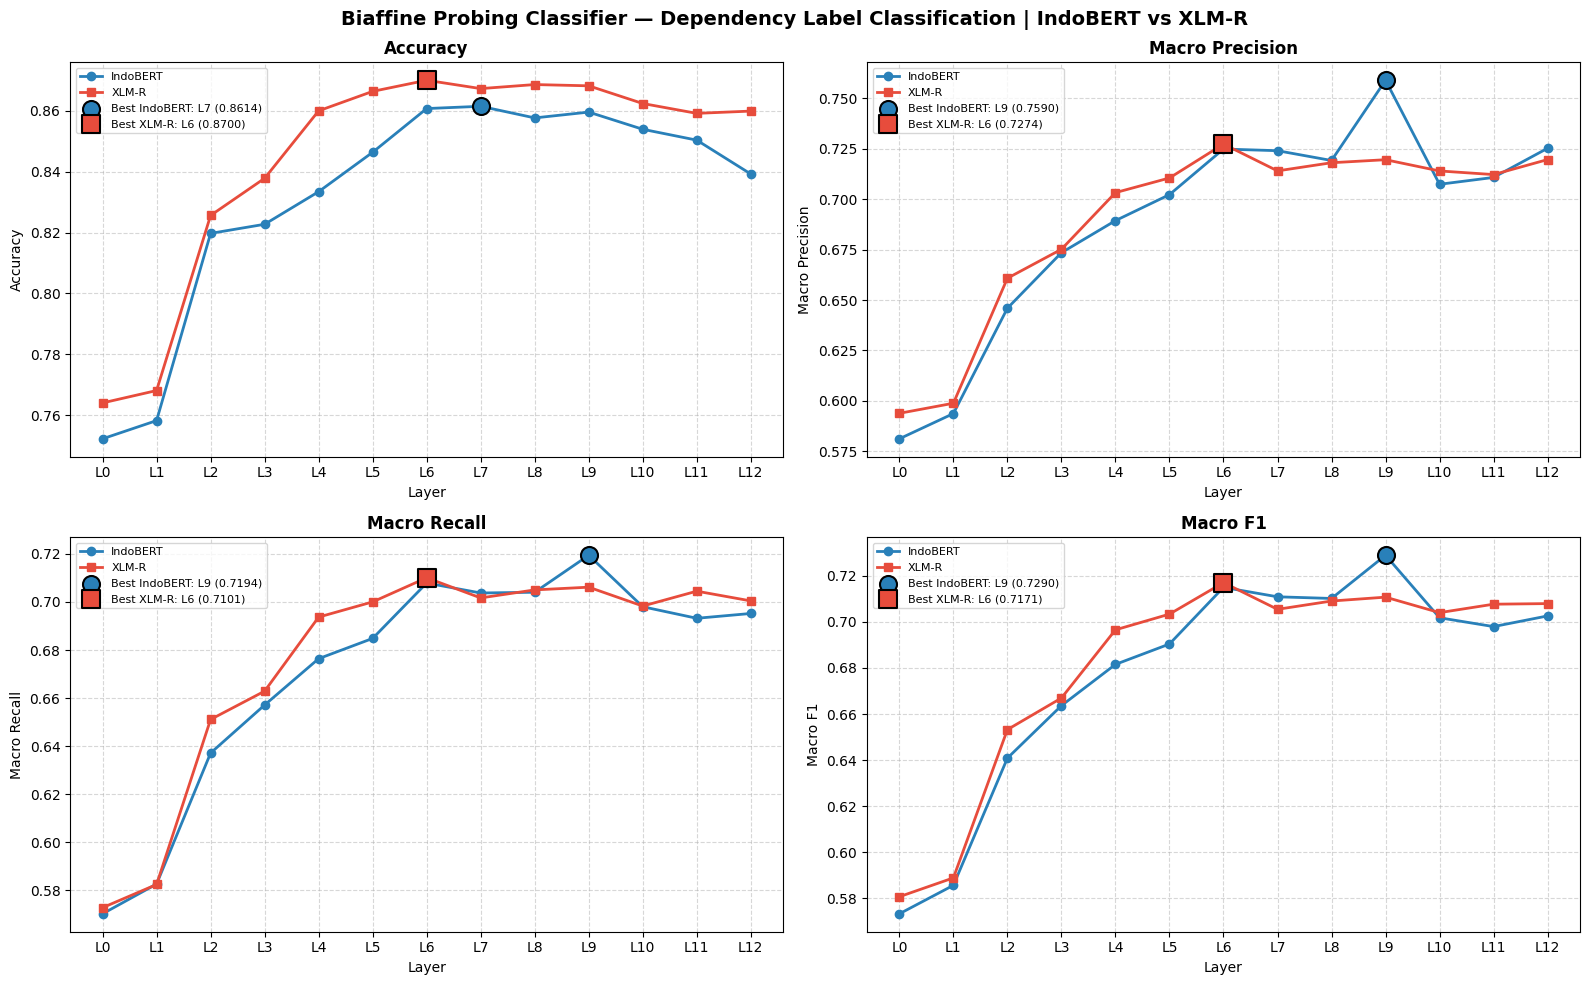

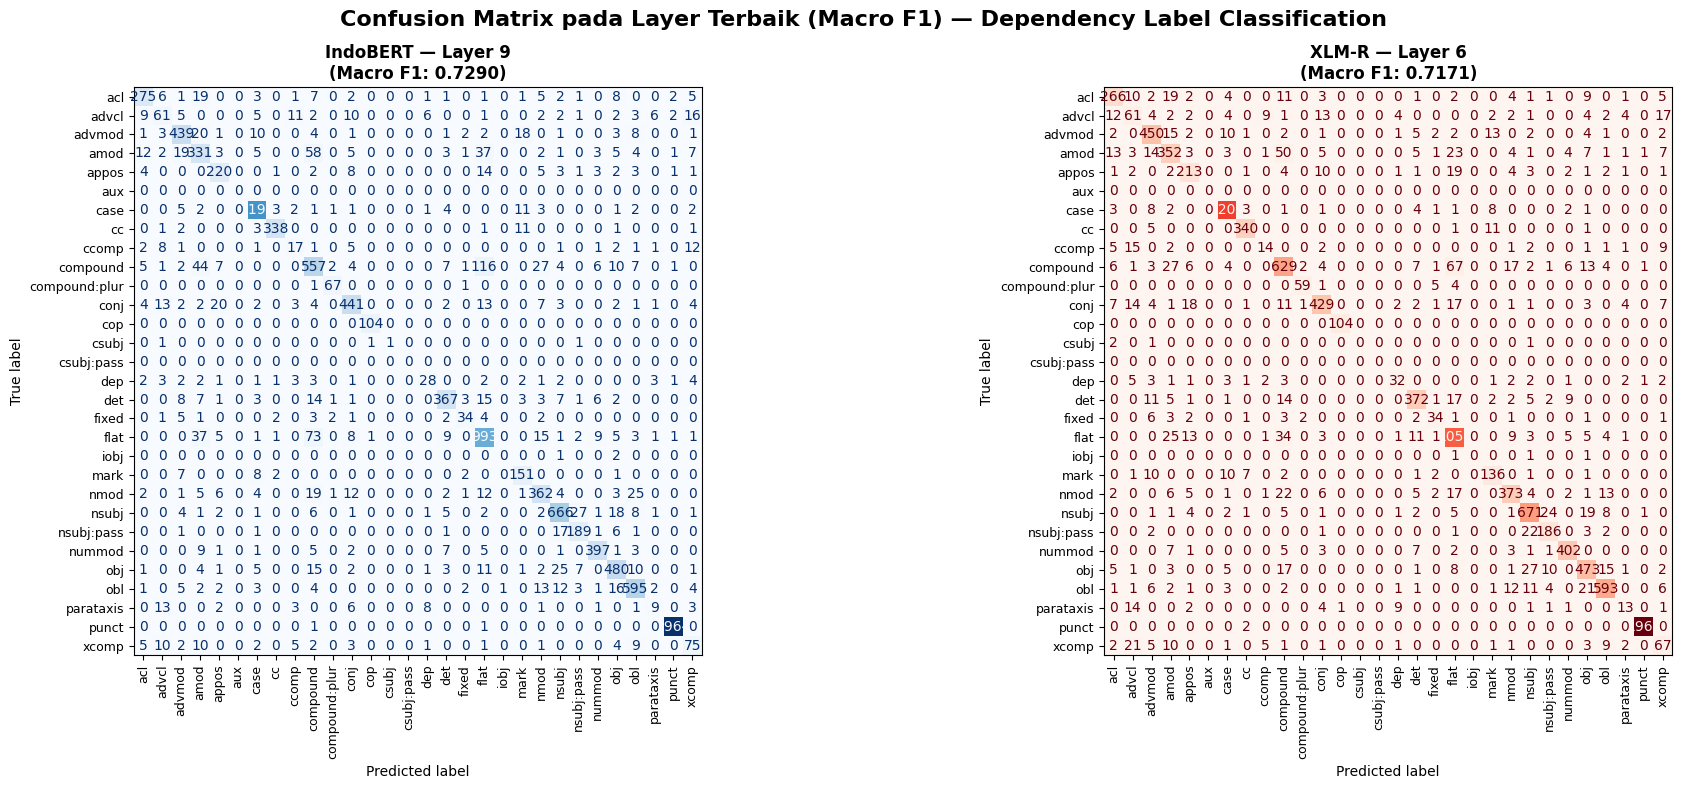


──────────────────────────────────────────────────────────────────────────────────
  RINGKASAN HASIL BIAFFINE PROBE — DEPENDENCY LABEL CLASSIFICATION
──────────────────────────────────────────────────────────────────────────────────
                    ── IndoBERT ──                          ── XLM-R ──             
Layer        Acc    Prec     Rec     mF1        Acc    Prec     Rec     mF1
──────────────────────────────────────────────────────────────────────────────────
L0        0.7523  0.5812  0.5702  0.5732     0.7640  0.5938  0.5728  0.5806
L1        0.7582  0.5937  0.5826  0.5855     0.7681  0.5988  0.5824  0.5888
L2        0.8197  0.6459  0.6371  0.6408     0.8256  0.6608  0.6511  0.6532
L3        0.8227  0.6735  0.6571  0.6636     0.8378  0.6752  0.6629  0.6669
L4        0.8334  0.6894  0.6764  0.6816     0.8600  0.7033  0.6937  0.6966
L5        0.8463  0.7023  0.6848  0.6904     0.8663  0.7106  0.7000  0.7034
L6        0.8607  0.7249  0.7079  0.7151     0.8700  0.7274  0.710

In [9]:
# ============================================================
# TAHAP 6: TRAINING BIAFFINE PROBE PER LAYER
# ============================================================

DIM_ARC = 128

class BiaffineProbe(nn.Module):
    def __init__(self, hidden_size, dim_arc, num_classes):
        super().__init__()

        # Dua MLP terpisah agar model belajar peran yang berbeda:
        # MLP_dep  → merepresentasikan token sebagai DEPENDENT
        # MLP_head → merepresentasikan token sebagai HEAD
        self.mlp_dep  = nn.Sequential(
            nn.Linear(hidden_size, dim_arc),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1)
        )
        self.mlp_head = nn.Sequential(
            nn.Linear(hidden_size, dim_arc),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1)
        )

        # Weight biaffine: (num_classes, dim_arc, dim_arc)
        self.biaffine = nn.Parameter(torch.zeros(num_classes, dim_arc, dim_arc))
        for k in range(num_classes):
            nn.init.xavier_uniform_(self.biaffine[k])

        self.bias = nn.Parameter(torch.zeros(num_classes))

    def forward(self, h_dep, h_head):
        u = self.mlp_dep (h_dep)    # (batch, dim_arc)
        v = self.mlp_head(h_head)   # (batch, dim_arc)

        # einsum 'bi,kij,bj->bk': b=batch, i=dim dep, j=dim head, k=num_classes
        scores = torch.einsum('bi,kij,bj->bk', u, self.biaffine, v)
        return scores + self.bias   # (batch, num_classes)


def train_biaffine_probe(X_dep_train, X_head_train, y_train,
                         X_dep_dev,   X_head_dev,   y_dev,
                         hidden_size  = HIDDEN_SIZE,
                         dim_arc      = DIM_ARC,
                         num_classes  = DEP_NUM_CLASSES,
                         epochs       = 15,
                         lr           = 2e-3,
                         batch_size   = 128,
                         return_preds = False):
    """
    Melatih BiaffineProbe untuk satu layer.
    Return: (acc, f1, precision, recall) atau + y_pred jika return_preds=True
    """
    Xd_tr = torch.tensor(X_dep_train,  dtype=torch.float32)
    Xh_tr = torch.tensor(X_head_train, dtype=torch.float32)
    y_tr  = torch.tensor(y_train,      dtype=torch.long)

    Xd_dv = torch.tensor(X_dep_dev,    dtype=torch.float32)
    Xh_dv = torch.tensor(X_head_dev,   dtype=torch.float32)
    y_dv  = torch.tensor(y_dev,        dtype=torch.long)

    loader = DataLoader(
        TensorDataset(Xd_tr, Xh_tr, y_tr),
        batch_size=batch_size, shuffle=True
    )

    probe     = BiaffineProbe(hidden_size, dim_arc, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    for epoch in range(epochs):
        probe.train()
        for Xd_b, Xh_b, y_b in loader:
            Xd_b, Xh_b, y_b = Xd_b.to(device), Xh_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(probe(Xd_b, Xh_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(probe.parameters(), max_norm=5.0)
            optimizer.step()
        scheduler.step()

    probe.eval()
    with torch.no_grad():
        y_pred = probe(
            Xd_dv.to(device),
            Xh_dv.to(device)
        ).argmax(dim=1).cpu().numpy()

    y_np = y_dv.numpy()
    acc  = accuracy_score(y_np, y_pred)
    f1   = f1_score(y_np, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_np, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_np, y_pred, average='macro', zero_division=0)

    if return_preds:
        return acc, f1, prec, rec, y_pred
    return acc, f1, prec, rec


# ── Training per Layer ────────────────────────────────────────────────────
layer_ticks = [f"L{i}" for i in range(NUM_LAYERS)]
results_dep = {
    'indobert': {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1': [], 'precision': [], 'recall': [], 'y_pred': []}
}

print("\n" + "=" * 85)
print("TRAINING BIAFFINE PROBE PER LAYER — DEPENDENCY LABEL CLASSIFICATION")
print("=" * 85)
print(f"{'Layer':<7} {'IB Acc':>7} {'IB P':>7} {'IB R':>7} {'IB mF1':>7} │ "
      f"{'XLM Acc':>7} {'XLM P':>7} {'XLM R':>7} {'XLM mF1':>8}")
print("-" * 85)

for layer_idx in range(NUM_LAYERS):

    dep_tr_ib   = data_dep_ib ['dep_train'] [:, layer_idx, :]
    head_tr_ib  = data_dep_ib ['head_train'][:, layer_idx, :]
    dep_dv_ib   = data_dep_ib ['dep_dev']   [:, layer_idx, :]
    head_dv_ib  = data_dep_ib ['head_dev']  [:, layer_idx, :]

    dep_tr_xlm  = data_dep_xlm['dep_train'] [:, layer_idx, :]
    head_tr_xlm = data_dep_xlm['head_train'][:, layer_idx, :]
    dep_dv_xlm  = data_dep_xlm['dep_dev']   [:, layer_idx, :]
    head_dv_xlm = data_dep_xlm['head_dev']  [:, layer_idx, :]

    acc_i, f1_i, prec_i, rec_i, pred_i = train_biaffine_probe(
        dep_tr_ib,  head_tr_ib,  y_dep_tr,
        dep_dv_ib,  head_dv_ib,  y_dep_dv,
        return_preds=True
    )
    acc_x, f1_x, prec_x, rec_x, pred_x = train_biaffine_probe(
        dep_tr_xlm, head_tr_xlm, y_dep_tr,
        dep_dv_xlm, head_dv_xlm, y_dep_dv,
        return_preds=True
    )

    for key, vals in [
        ('indobert', (acc_i, f1_i, prec_i, rec_i, pred_i)),
        ('xlmr',     (acc_x, f1_x, prec_x, rec_x, pred_x))
    ]:
        results_dep[key]['acc'].append(vals[0])
        results_dep[key]['f1'].append(vals[1])
        results_dep[key]['precision'].append(vals[2])
        results_dep[key]['recall'].append(vals[3])
        results_dep[key]['y_pred'].append(vals[4])

    print(f"L{layer_idx:<6} {acc_i:>7.4f} {prec_i:>7.4f} {rec_i:>7.4f} {f1_i:>7.4f} │ "
          f"{acc_x:>7.4f} {prec_x:>7.4f} {rec_x:>7.4f} {f1_x:>8.4f}")

print("=" * 85)

# ── Indeks layer terbaik ──────────────────────────────────────────────────
best_dep = {
    model: {m: int(np.argmax(results_dep[model][m]))
            for m in ['acc', 'f1', 'precision', 'recall']}
    for model in ['indobert', 'xlmr']
}

# ── Visualisasi Line Plot (Acc, Macro Precision, Macro Recall, Macro F1) ──
metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Macro Precision'),
    ('recall',    'Macro Recall'),
    ('f1',        'Macro F1'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Biaffine Probing Classifier — Dependency Label Classification | IndoBERT vs XLM-R',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    b_i = best_dep['indobert'][metric]
    b_x = best_dep['xlmr'][metric]

    ax.plot(layer_ticks, results_dep['indobert'][metric],
            marker='o', linewidth=2, label='IndoBERT', color='#2980b9')
    ax.plot(layer_ticks, results_dep['xlmr'][metric],
            marker='s', linewidth=2, label='XLM-R',    color='#e74c3c')

    ax.scatter(b_i, results_dep['indobert'][metric][b_i],
               s=150, zorder=5, color='#2980b9', edgecolors='black', linewidths=1.5,
               label=f'Best IndoBERT: L{b_i} ({results_dep["indobert"][metric][b_i]:.4f})')
    ax.scatter(b_x, results_dep['xlmr'][metric][b_x],
               s=150, zorder=5, color='#e74c3c', marker='s', edgecolors='black', linewidths=1.5,
               label=f'Best XLM-R: L{b_x} ({results_dep["xlmr"][metric][b_x]:.4f})')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(layer_ticks)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Confusion Matrix pada Layer Terbaik Macro F1 ─────────────────────────
CLASS_NAMES_DEP  = list(dep_label_encoder.classes_)
all_class_labels = list(range(DEP_NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Confusion Matrix pada Layer Terbaik (Macro F1) — Dependency Label Classification',
             fontsize=16, fontweight='bold')

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    b  = best_dep[model_key]['f1']
    cm = confusion_matrix(
        y_dep_dv,
        results_dep[model_key]['y_pred'][b],
        labels=all_class_labels
    )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES_DEP)
    disp.plot(ax=ax, colorbar=False, cmap=color, xticks_rotation=90)
    ax.set_title(f'{model_name} — Layer {b}\n'
                 f'(Macro F1: {results_dep[model_key]["f1"][b]:.4f})',
                 fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()

# ── Tabel Ringkasan ───────────────────────────────────────────────────────
METRICS_DEP = [('acc', 'Acc'), ('precision', 'Prec'), ('recall', 'Rec'), ('f1', 'mF1')]

best_ib_row  = best_dep['indobert']['f1']
best_xlm_row = best_dep['xlmr']['f1']

col_w          = 8
sep            = "─" * (7 + (col_w + 1) * 4 + 3 + (col_w + 1) * 4)
header_metrics = "".join(f"{lbl:>{col_w}}" for _, lbl in METRICS_DEP)

print(f"\n{'─' * len(sep)}")
print(f"  RINGKASAN HASIL BIAFFINE PROBE — DEPENDENCY LABEL CLASSIFICATION")
print(f"{'─' * len(sep)}")
print(f"{'':7}  {'── IndoBERT ──':^{(col_w+1)*4}}   {'── XLM-R ──':^{(col_w+1)*4}}")
print(f"{'Layer':<7} {header_metrics}   {header_metrics}")
print(f"{'─' * len(sep)}")

for i in range(NUM_LAYERS):
    ib_vals  = "".join(f"{results_dep['indobert'][m][i]:>{col_w}.4f}" for m, _ in METRICS_DEP)
    xlm_vals = "".join(f"{results_dep['xlmr'][m][i]:>{col_w}.4f}"     for m, _ in METRICS_DEP)
    tag = " ✦ best IB"  if i == best_ib_row  else \
          " ✦ best XLM" if i == best_xlm_row else ""
    print(f"L{i:<6} {ib_vals}   {xlm_vals}{tag}")

print(f"{'─' * len(sep)}")


### 7. Analisis Geometris: Center Kernel Alignment (CKA) - Similarity

Membangun edge representation untuk CKA...
✅ Shape CKA: (1000, 13, 1536)
Menghitung CKA internal IndoBERT...
Menghitung CKA internal XLM-R...
Menghitung CKA cross-model per layer...


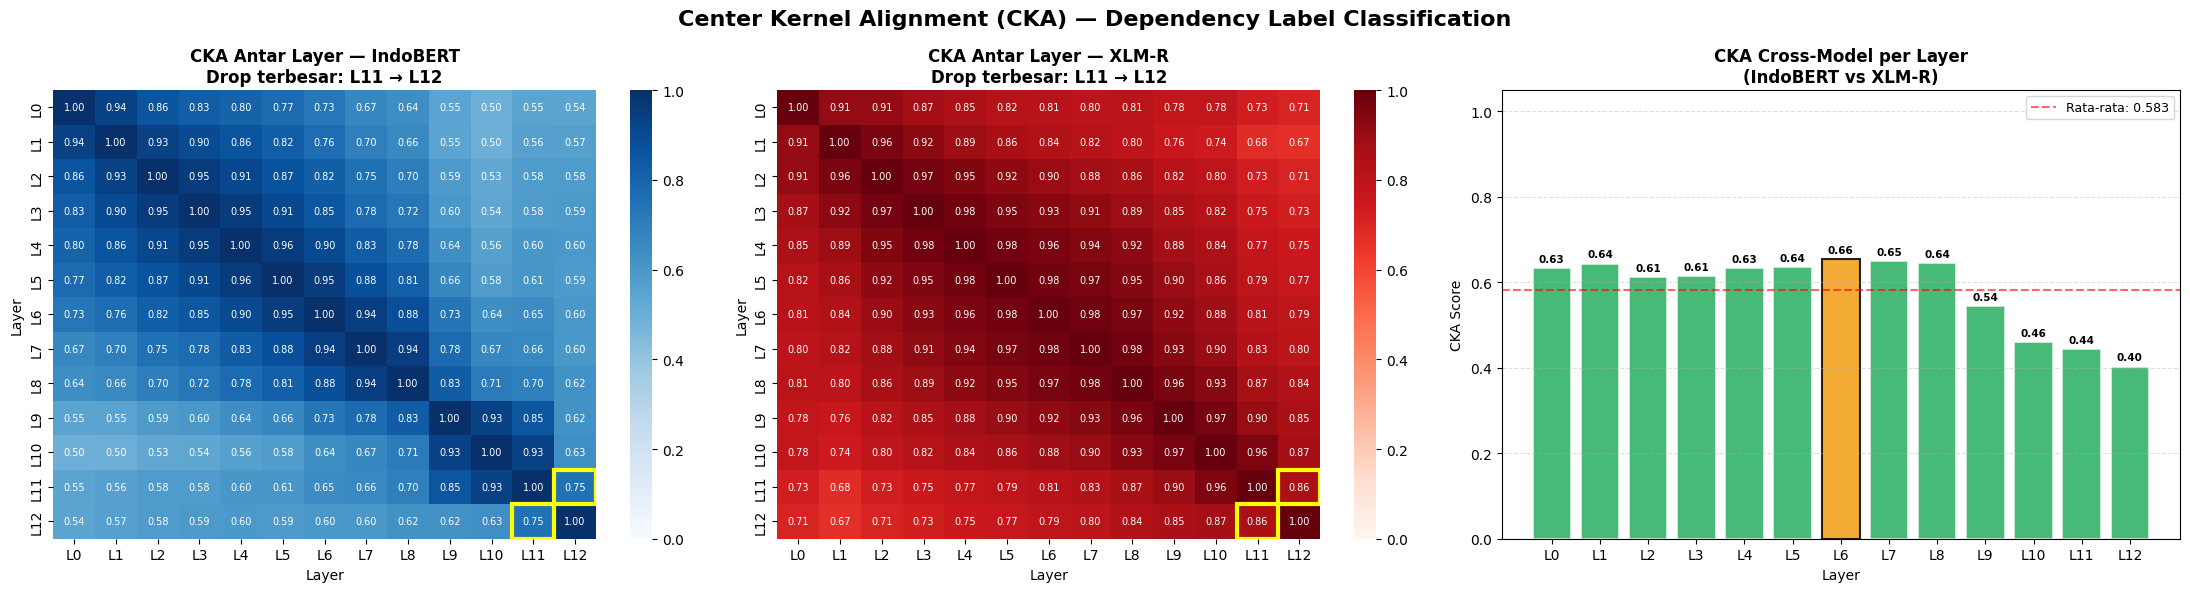

In [10]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA) — DEPENDENCY
# ============================================================

# ------------------------------------------------------------
# 1) FUNGSI CKA (VERSI CEPAT)
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    """Hitung CKA antar semua pasangan layer (memanfaatkan simetri)."""
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):   # ← hanya segitiga atas
            val = linear_cka(
                X_layers[:, i, :].astype(np.float32),  # ← float32 lebih cepat
                X_layers[:, j, :].astype(np.float32)
            )
            M[i, j] = val
            M[j, i] = val       # ← isi simetrinya sekalian
    return M

# ------------------------------------------------------------
# 2) FUNGSI HIGHLIGHT
# ------------------------------------------------------------

def highlight_sequential_max(ax, cka_matrix):
    """Highlight pasangan layer berurutan dengan drop terbesar."""
    n = cka_matrix.shape[0]
    seq_cka  = np.array([cka_matrix[i, i+1] for i in range(n-1)])
    seq_drop = 1 - seq_cka
    best_idx = int(np.argmax(seq_drop))

    rect1 = plt.Rectangle((best_idx+1, best_idx),   1, 1,
                           fill=False, edgecolor='yellow', linewidth=3)
    rect2 = plt.Rectangle((best_idx,   best_idx+1), 1, 1,
                           fill=False, edgecolor='yellow', linewidth=3)
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    return best_idx, seq_cka, seq_drop

# ------------------------------------------------------------
# 3) SAMPLING & BANGUN EDGE REPRESENTATION
# ------------------------------------------------------------

MAX_CKA = 1000
n_test  = data_dep_ib['dep_test'].shape[0]

np.random.seed(42)
idx_cka = np.random.choice(n_test, size=min(MAX_CKA, n_test), replace=False)

# float32 dari awal — lebih cepat saat komputasi CKA
X_cka_ib  = np.zeros((len(idx_cka), NUM_LAYERS, HIDDEN_SIZE * 2), dtype=np.float32)
X_cka_xlm = np.zeros((len(idx_cka), NUM_LAYERS, HIDDEN_SIZE * 2), dtype=np.float32)

print("Membangun edge representation untuk CKA...")
for layer_idx in range(NUM_LAYERS):
    dep_ib   = data_dep_ib ['dep_test'] [idx_cka, layer_idx, :]
    head_ib  = data_dep_ib ['head_test'][idx_cka, layer_idx, :]
    dep_xlm  = data_dep_xlm['dep_test'] [idx_cka, layer_idx, :]
    head_xlm = data_dep_xlm['head_test'][idx_cka, layer_idx, :]

    X_cka_ib [:, layer_idx, :] = np.concatenate([dep_ib,  head_ib ], axis=1)
    X_cka_xlm[:, layer_idx, :] = np.concatenate([dep_xlm, head_xlm], axis=1)

print(f"✅ Shape CKA: {X_cka_ib.shape}")

# ------------------------------------------------------------
# 4) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT...")
cka_dep_ib    = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R...")
cka_dep_xlm   = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_dep_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])

# ------------------------------------------------------------
# 5) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — Dependency Label Classification',
             fontsize=16, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_dep_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_dep_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')

# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_dep_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_dep_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')

# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_dep_cross,
    color='#27ae60',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross_dep = int(np.argmax(cka_dep_cross))

bars[best_cross_dep].set_color('#f39c12')
bars[best_cross_dep].set_edgecolor('black')
bars[best_cross_dep].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_dep_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_dep_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_dep_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()

## D. Negasi (Semantic) - *Negation Scope Detection*

### 1. Load Dataset dan Encode Label

Skema label dari Dataset.ipynb:
- `Kata Negasi` = token negasi itu sendiri (misal: *tidak*, *bukan*, *tidaklah*)
- `In_Scope`    = token yang berada di dalam scope negasi
- `Out_Scope`   = token di luar scope negasi

Input X  : Hidden state satu token per layer → shape `(n_token, 13, 768)`
Output Y : Label encoded `{In_Scope: 0, Kata Negasi: 1, Out_Scope: 2}`

In [11]:
# ============================================================
# TAHAP 1: LOAD DATASET NEGATION SCOPE DETECTION
# ============================================================

BASE_PROCESSED_NEG = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Negasi"

COLS_KEEP_NEG = ['sent_id', 'token_id', 'token', 'negasi_scope']

df_neg_train_raw = pd.read_csv(os.path.join(BASE_PROCESSED_NEG, "ud-indo-gsd_train_negation.csv"))
df_neg_dev_raw   = pd.read_csv(os.path.join(BASE_PROCESSED_NEG, "ud-indo-gsd_dev_negation.csv"))
df_neg_test_raw  = pd.read_csv(os.path.join(BASE_PROCESSED_NEG, "ud-indo-gsd_test_negation.csv"))

df_neg_train = df_neg_train_raw[COLS_KEEP_NEG].copy()
df_neg_dev   = df_neg_dev_raw  [COLS_KEEP_NEG].copy()
df_neg_test  = df_neg_test_raw [COLS_KEEP_NEG].copy()

# Verifikasi label unik sebelum encode
all_labels = (
    set(df_neg_train['negasi_scope'].unique()) |
    set(df_neg_dev  ['negasi_scope'].unique()) |
    set(df_neg_test ['negasi_scope'].unique())
)
print(f"Label unik di seluruh split: {all_labels}")
# Harusnya: {'In_Scope', 'Kata Negasi', 'Out_Scope'}

# Encode label — sesuai label asli dari Dataset.ipynb
neg_label_encoder = LabelEncoder()
neg_label_encoder.fit(['In_Scope', 'Kata Negasi', 'Out_Scope'])
# Hasil: In_Scope=0, Kata Negasi=1, Out_Scope=2

df_neg_train['label_encoded'] = neg_label_encoder.transform(df_neg_train['negasi_scope'])
df_neg_dev  ['label_encoded'] = neg_label_encoder.transform(df_neg_dev  ['negasi_scope'])
df_neg_test ['label_encoded'] = neg_label_encoder.transform(df_neg_test ['negasi_scope'])

NEG_NUM_CLASSES = len(neg_label_encoder.classes_)   # 3
NUM_LAYERS      = 13
HIDDEN_SIZE     = 768

print("=" * 55)
print("INFO DATASET NEGATION SCOPE DETECTION")
print("=" * 55)
print(f"Kolom X      : ['sent_id', 'token_id', 'token']")
print(f"Kolom Y      : negasi_scope")
print(f"Kelas label  : {list(neg_label_encoder.classes_)}")
print(f"              (indeks: {list(range(NEG_NUM_CLASSES))})")
print(f"Train        : {len(df_neg_train):,} token")
print(f"Dev          : {len(df_neg_dev):,} token")
print(f"Test         : {len(df_neg_test):,} token")

print(f"\nDistribusi label (train):")
for label in neg_label_encoder.classes_:
    n   = (df_neg_train['negasi_scope'] == label).sum()
    pct = n / len(df_neg_train) * 100
    print(f"  {label:<15}: {n:>6,} ({pct:.1f}%)")

Label unik di seluruh split: {'Out_Scope', 'Kata Negasi', 'In_Scope'}
INFO DATASET NEGATION SCOPE DETECTION
Kolom X      : ['sent_id', 'token_id', 'token']
Kolom Y      : negasi_scope
Kelas label  : [np.str_('In_Scope'), np.str_('Kata Negasi'), np.str_('Out_Scope')]
              (indeks: [0, 1, 2])
Train        : 9,232 token
Dev          : 1,066 token
Test         : 1,044 token

Distribusi label (train):
  In_Scope       :  3,742 (40.5%)
  Kata Negasi    :    445 (4.8%)
  Out_Scope      :  5,045 (54.6%)


### 2. Ekstraksi Hidden States

Yang dilakukan:
1. Mengekstrak hidden states semua layer untuk setiap token
2. Satu token → satu vektor per layer (sama dengan Morfologi & POS Tagging)

Input:
1. `df`: DataFrame dengan kolom `[sent_id, token_id, token, negasi_scope]`
2. `tokenizer`, `model`: model HuggingFace yang sudah di-load

Output (disimpan ke disk per layer):
- `X[idx_token, layer, :]` → vektor hidden state token pada layer tertentu
- `y` → label encoded per token

In [12]:
# ============================================================
# TAHAP 2: FUNGSI EKSTRAKSI HIDDEN STATES — NEGATION SCOPE
# ============================================================

def extract_hidden_states_neg(df, tokenizer, model, save_dir, prefix, device):
    """
    Ekstrak hidden states per token untuk Negation Scope Detection.
    Disimpan per layer ke disk untuk menghemat RAM.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Inisialisasi buffer per layer
    all_X = [[] for _ in range(NUM_LAYERS)]
    all_y = []

    grouped = list(df.groupby('sent_id'))

    for sent_id, df_sent in tqdm(grouped, desc=f"Ekstraksi {prefix}"):
        tokens      = df_sent['token'].tolist()
        labels      = df_sent['label_encoded'].tolist()
        token_ids   = df_sent['token_id'].tolist()

        # Tokenisasi
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding=False
        )

        input_ids      = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        word_ids       = encoding.word_ids(batch_index=0)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )

        # hidden_states: tuple of (1, seq_len, 768) × 13 layer
        hidden_states = outputs.hidden_states

        # Mapping word_id → subword pertama (first-subword strategy)
        word_to_first_subword = {}
        for subword_idx, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in word_to_first_subword:
                word_to_first_subword[word_idx] = subword_idx

        # Kumpulkan per token
        for tok_pos, label in enumerate(labels):
            if tok_pos not in word_to_first_subword:
                continue
            subword_idx = word_to_first_subword[tok_pos]

            for layer_idx in range(NUM_LAYERS):
                vec = hidden_states[layer_idx][0, subword_idx, :].cpu().numpy()
                all_X[layer_idx].append(vec)

            all_y.append(label)

    # Simpan ke disk per layer
    y_arr = np.array(all_y, dtype=np.int32)
    np.save(os.path.join(save_dir, f"{prefix}_neg_y.npy"), y_arr)

    for layer_idx in range(NUM_LAYERS):
        X_layer = np.array(all_X[layer_idx], dtype=np.float32)
        np.savez_compressed(
            os.path.join(save_dir, f"{prefix}_neg_L{layer_idx}.npz"),
            X=X_layer
        )

    print(f"✅ {prefix}: {len(all_y):,} token tersimpan ({NUM_LAYERS} layer)")
    return y_arr




SAVE_DIR_NEG = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Negasi"
os.makedirs(SAVE_DIR_NEG, exist_ok=True)

### 3. Eksekusi Ekstraksi: IndoBERT

Direktori Hidden States Negasi:

In [13]:
SAVE_DIR_NEG = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\notebook\Ekstraksi_Hidden_States\Negasi"
os.makedirs(SAVE_DIR_NEG, exist_ok=True)

Ekstraksi IndoBERT:

In [63]:
# ============================================================
# TAHAP 3: EKSTRAKSI FITUR (INDOBERT) & SIMPAN KE DISK
# ============================================================
# ⚠ Jalankan SEKALI saja. Jika sudah ada file .npz, skip cell ini.

print("=" * 60)
print("EKSTRAKSI HIDDEN STATES — INDOBERT (NEGATION SCOPE)")
print("=" * 60)

for split_name, df_split in [("train", df_neg_train),
                              ("dev",   df_neg_dev),
                              ("test",  df_neg_test)]:
    print(f"\n→ Split: {split_name} ({len(df_split):,} token)")
    extract_hidden_states_neg(
        df        = df_split,
        tokenizer = tokenizer_indobert,
        model     = model_indobert,
        save_dir  = SAVE_DIR_NEG,
        prefix    = f"indobert_{split_name}",
        device    = device
    )

print("\n✅ Ekstraksi IndoBERT (Negation Scope) selesai!")

EKSTRAKSI HIDDEN STATES — INDOBERT (NEGATION SCOPE)

→ Split: train (9,232 token)


Ekstraksi indobert_train: 100%|██████████| 405/405 [00:13<00:00, 28.95it/s]


✅ indobert_train: 9,230 token tersimpan (13 layer)

→ Split: dev (1,066 token)


Ekstraksi indobert_dev: 100%|██████████| 46/46 [00:01<00:00, 25.12it/s]


✅ indobert_dev: 1,066 token tersimpan (13 layer)

→ Split: test (1,044 token)


Ekstraksi indobert_test: 100%|██████████| 44/44 [00:01<00:00, 26.92it/s]


✅ indobert_test: 1,044 token tersimpan (13 layer)

✅ Ekstraksi IndoBERT (Negation Scope) selesai!


### 4. Eksekusi Ekstraksi: XLM-R

In [64]:
# ============================================================
# TAHAP 4: EKSTRAKSI FITUR (XLM-R) & SIMPAN KE DISK
# ============================================================
# ⚠ Jalankan SEKALI saja. Jika sudah ada file .npz, skip cell ini.

print("\n" + "=" * 60)
print("EKSTRAKSI HIDDEN STATES — XLM-R (NEGATION SCOPE)")
print("=" * 60)

for split_name, df_split in [("train", df_neg_train),
                              ("dev",   df_neg_dev),
                              ("test",  df_neg_test)]:
    print(f"\n→ Split: {split_name} ({len(df_split):,} token)")
    extract_hidden_states_neg(
        df        = df_split,
        tokenizer = tokenizer_xlmr,
        model     = model_xlmr,
        save_dir  = SAVE_DIR_NEG,
        prefix    = f"xlmr_{split_name}",
        device    = device
    )

print("\n✅ Ekstraksi XLM-R (Negation Scope) selesai!")


EKSTRAKSI HIDDEN STATES — XLM-R (NEGATION SCOPE)

→ Split: train (9,232 token)


Ekstraksi xlmr_train: 100%|██████████| 405/405 [00:15<00:00, 25.44it/s]


✅ xlmr_train: 9,230 token tersimpan (13 layer)

→ Split: dev (1,066 token)


Ekstraksi xlmr_dev: 100%|██████████| 46/46 [00:01<00:00, 25.63it/s]


✅ xlmr_dev: 1,066 token tersimpan (13 layer)

→ Split: test (1,044 token)


Ekstraksi xlmr_test: 100%|██████████| 44/44 [00:01<00:00, 23.36it/s]


✅ xlmr_test: 1,044 token tersimpan (13 layer)

✅ Ekstraksi XLM-R (Negation Scope) selesai!


### 5. Load Hasil Ekstraksi Hidden States

In [14]:
# ============================================================
# TAHAP 5: LOAD DARI DISK
# ============================================================

print("Memuat hidden states dari disk...")

# Label
y_neg_train_ib = np.load(os.path.join(SAVE_DIR_NEG, "indobert_train_neg_y.npy"))
y_neg_dev_ib   = np.load(os.path.join(SAVE_DIR_NEG, "indobert_dev_neg_y.npy"))
y_neg_test_ib  = np.load(os.path.join(SAVE_DIR_NEG, "indobert_test_neg_y.npy"))

y_neg_train_xlm = np.load(os.path.join(SAVE_DIR_NEG, "xlmr_train_neg_y.npy"))
y_neg_dev_xlm   = np.load(os.path.join(SAVE_DIR_NEG, "xlmr_dev_neg_y.npy"))
y_neg_test_xlm  = np.load(os.path.join(SAVE_DIR_NEG, "xlmr_test_neg_y.npy"))

# Hidden states per layer → shape (n_token, NUM_LAYERS, HIDDEN_SIZE)
def load_hidden_neg(prefix):
    layers = []
    for i in range(NUM_LAYERS):
        data = np.load(os.path.join(SAVE_DIR_NEG, f"{prefix}_neg_L{i}.npz"))
        layers.append(data['X'])                         # (n_token, 768)
    return np.stack(layers, axis=1)                      # (n_token, 13, 768)

X_neg_train_ib  = load_hidden_neg("indobert_train")
X_neg_dev_ib    = load_hidden_neg("indobert_dev")
X_neg_test_ib   = load_hidden_neg("indobert_test")

X_neg_train_xlm = load_hidden_neg("xlmr_train")
X_neg_dev_xlm   = load_hidden_neg("xlmr_dev")
X_neg_test_xlm  = load_hidden_neg("xlmr_test")

print(f"✅ Shape IndoBERT train : {X_neg_train_ib.shape}")
print(f"✅ Shape XLM-R train    : {X_neg_train_xlm.shape}")
print(f"✅ Label train (IB)     : {y_neg_train_ib.shape} — kelas: {np.unique(y_neg_train_ib)}")

Memuat hidden states dari disk...
✅ Shape IndoBERT train : (9230, 13, 768)
✅ Shape XLM-R train    : (9230, 13, 768)
✅ Label train (IB)     : (9230,) — kelas: [0 1 2]


### 6. Training Probing Classifier & Visualisasi

Karena label `Out_Scope` sangat dominan, metrik utama yang diperhatikan adalah **Weighted F1**
bukan Accuracy semata, agar performa pada kelas minoritas (`In_Scope`, `Kata Negasi`) tetap terevaluasi.


TRAINING PROBING CLASSIFIER PER LAYER — NEGATION SCOPE DETECTION
Layer    IB Acc    IB P    IB R  IB mF1 │ XLM Acc   XLM P   XLM R  XLM mF1
--------------------------------------------------------------------------------
L0       0.5769  0.6969  0.6967  0.6965 │  0.5741  0.6979  0.6788   0.6723
L1       0.6501  0.7500  0.7410  0.7429 │  0.6332  0.7398  0.7280   0.7275
L2       0.6407  0.7423  0.7295  0.7350 │  0.6323  0.7340  0.7272   0.7235
L3       0.6707  0.7577  0.7563  0.7562 │  0.6548  0.7547  0.7436   0.7445
L4       0.6848  0.7677  0.7720  0.7691 │  0.7129  0.7850  0.7790   0.7781
L5       0.7045  0.7820  0.7799  0.7799 │  0.7120  0.7890  0.7788   0.7813
L6       0.7195  0.8032  0.8006  0.7965 │  0.7176  0.7933  0.7941   0.7908
L7       0.7289  0.8082  0.8018  0.8013 │  0.7186  0.7928  0.7895   0.7893
L8       0.7280  0.8318  0.8044  0.7994 │  0.7355  0.8038  0.8075   0.8048
L9       0.7467  0.8250  0.8079  0.8098 │  0.7289  0.8005  0.8024   0.7994
L10      0.7514  0.8235  0.8

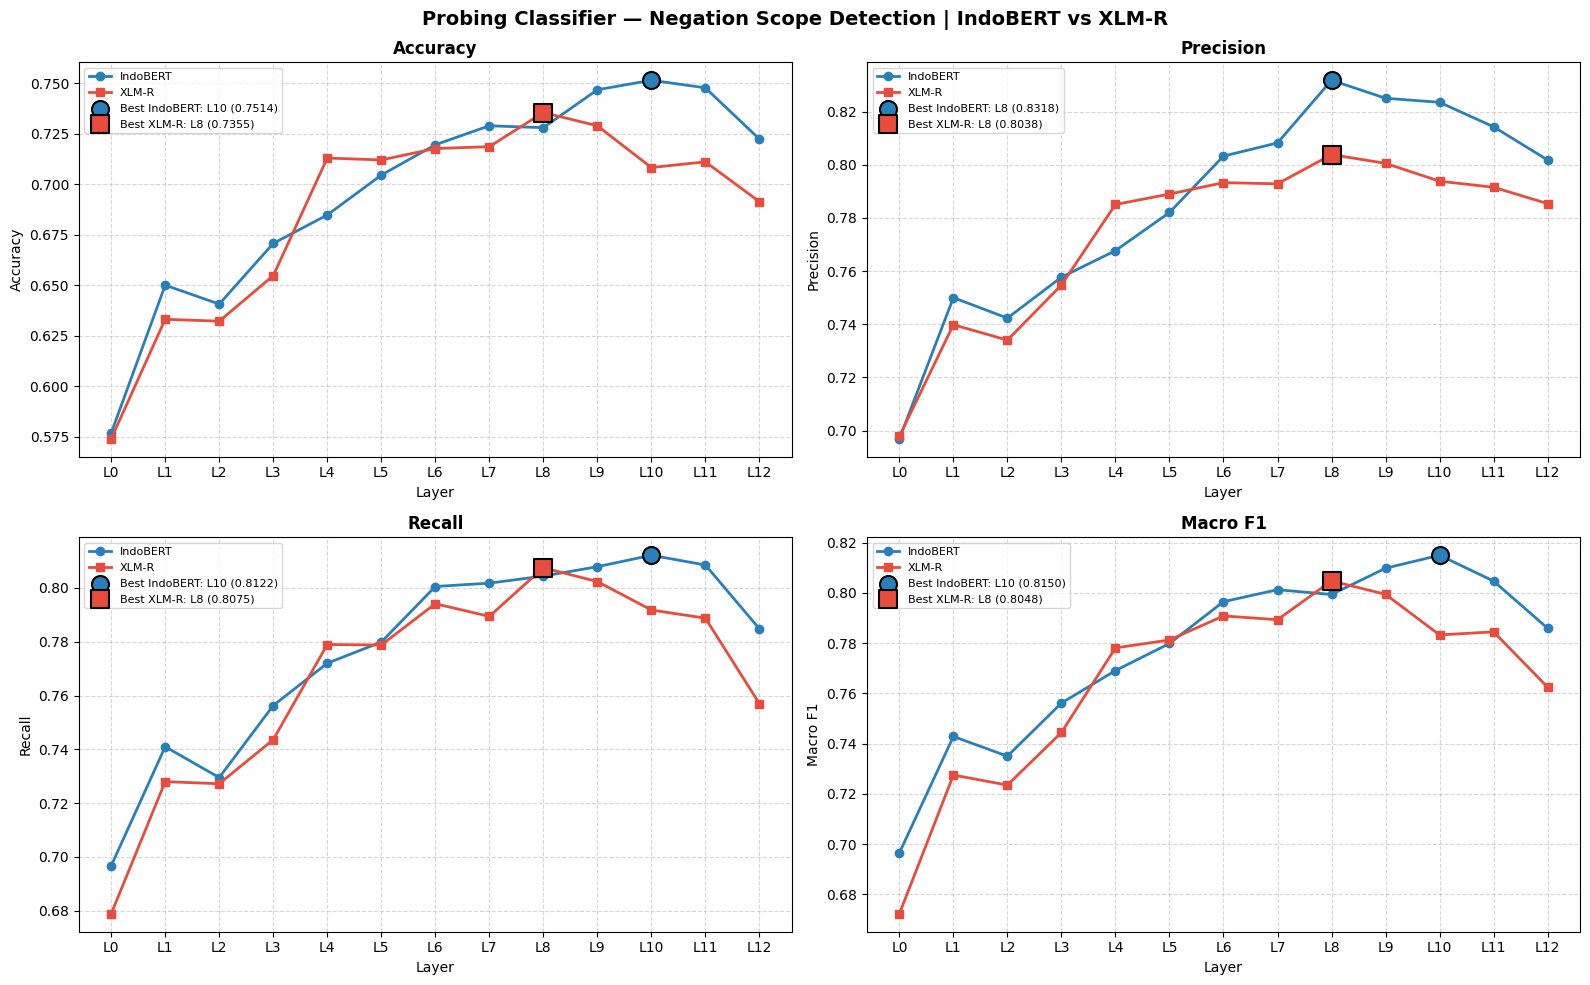

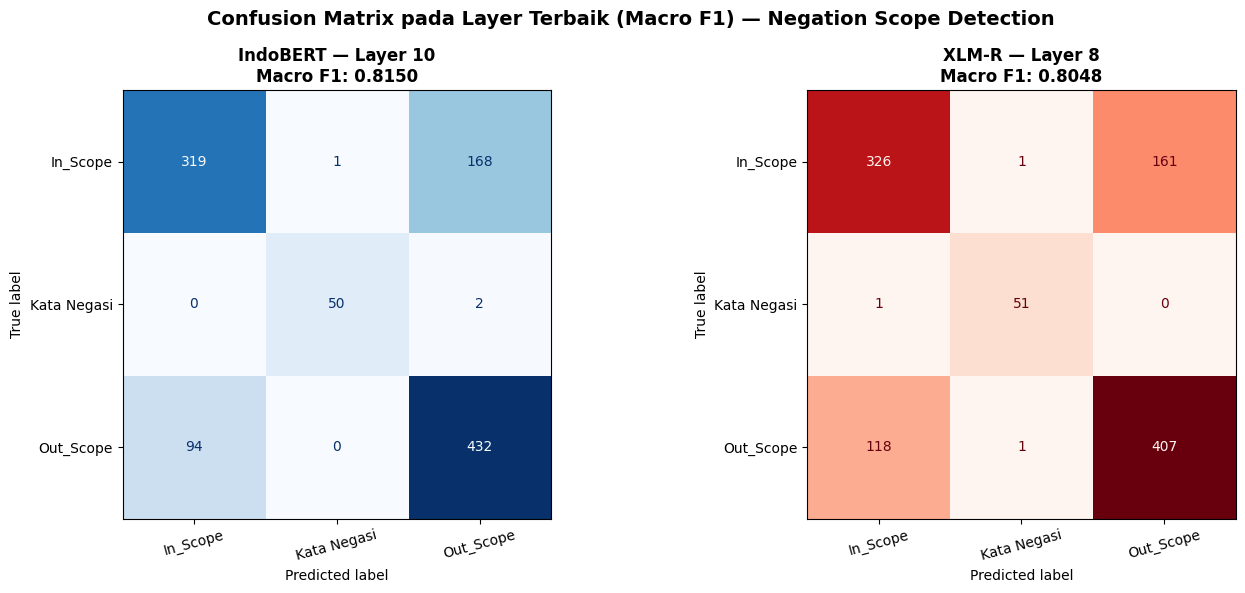


──────────────────────────────────────────────────────────────────────────────────────────
  RINGKASAN HASIL PROBING CLASSIFIER — NEGATION SCOPE DETECTION
  (Layer terbaik ditandai berdasarkan Macro F1)
──────────────────────────────────────────────────────────────────────────────────────────
                      ── IndoBERT ──                              ── XLM-R ──               
Layer         Acc     Prec      Rec      mF1         Acc     Prec      Rec      mF1
──────────────────────────────────────────────────────────────────────────────────────────
L0         0.5769   0.6969   0.6967   0.6965      0.5741   0.6979   0.6788   0.6723
L1         0.6501   0.7500   0.7410   0.7429      0.6332   0.7398   0.7280   0.7275
L2         0.6407   0.7423   0.7295   0.7350      0.6323   0.7340   0.7272   0.7235
L3         0.6707   0.7577   0.7563   0.7562      0.6548   0.7547   0.7436   0.7445
L4         0.6848   0.7677   0.7720   0.7691      0.7129   0.7850   0.7790   0.7781
L5         0.7045

In [19]:
# ==========================================================
# TAHAP 6: TRAINING PROBING CLASSIFIER & VISUALISASI
# ==========================================================

# ── Definisi Probing Classifier ───────────────────────────────────────────
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

def train_probe(X_train, y_train, X_eval, y_eval,
                hidden_size=768, num_classes=23,
                epochs=10, lr=1e-3, batch_size=64,
                return_preds=False):
    """Melatih probing classifier untuk satu layer. Return metrics & predictions."""
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_ev = torch.tensor(X_eval,  dtype=torch.float32)
    y_ev = torch.tensor(y_eval,  dtype=torch.long)

    loader    = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=batch_size, shuffle=True)
    probe     = LinearProbe(hidden_size, num_classes).to(device)
    optimizer = optim.Adam(probe.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        probe.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(probe(X_b), y_b).backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        y_pred = probe(X_ev.to(device)).argmax(dim=1).cpu().numpy()

    y_np  = y_ev.numpy()
    acc   = accuracy_score(y_np, y_pred)
    f1    = f1_score(y_np, y_pred, average='macro', zero_division=0)
    prec  = precision_score(y_np, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_np, y_pred, average='macro', zero_division=0)

    if return_preds:
        return acc, f1, prec, rec, y_pred
    return acc, f1, prec, rec

# ── Kontainer hasil ───────────────────────────────────────
results_neg = {
    'indobert': {'acc': [], 'f1_macro': [],
                 'precision': [], 'recall': [], 'y_pred': []},
    'xlmr'    : {'acc': [], 'f1_macro': [],
                 'precision': [], 'recall': [], 'y_pred': []}
}

print("\n" + "=" * 80)
print("TRAINING PROBING CLASSIFIER PER LAYER — NEGATION SCOPE DETECTION")
print("=" * 80)
print(f"{'Layer':<7} {'IB Acc':>7} {'IB P':>7} {'IB R':>7} {'IB mF1':>7} │ "
      f"{'XLM Acc':>7} {'XLM P':>7} {'XLM R':>7} {'XLM mF1':>8}")
print("-" * 80)

for layer_idx in range(NUM_LAYERS):
    # ── IndoBERT ─────────────────────────────────────────
    acc_i, _, prec_i, rec_i, pred_i = train_probe(
        X_neg_train_ib[:, layer_idx, :], y_neg_train_ib,
        X_neg_dev_ib[:,   layer_idx, :], y_neg_dev_ib,
        hidden_size=HIDDEN_SIZE, num_classes=NEG_NUM_CLASSES,
        return_preds=True
    )
    f1_macro_i = f1_score(y_neg_dev_ib, pred_i, average='macro', zero_division=0)

    # ── XLM-R ────────────────────────────────────────────
    acc_x, _, prec_x, rec_x, pred_x = train_probe(
        X_neg_train_xlm[:, layer_idx, :], y_neg_train_ib,
        X_neg_dev_xlm[:,   layer_idx, :], y_neg_dev_ib,
        hidden_size=HIDDEN_SIZE, num_classes=NEG_NUM_CLASSES,
        return_preds=True
    )
    f1_macro_x = f1_score(y_neg_dev_ib, pred_x, average='macro', zero_division=0)

    for key, vals in [
        ('indobert', (acc_i, f1_macro_i, prec_i, rec_i, pred_i)),
        ('xlmr',     (acc_x, f1_macro_x, prec_x, rec_x, pred_x))
    ]:
        results_neg[key]['acc'].append(vals[0])
        results_neg[key]['f1_macro'].append(vals[1])
        results_neg[key]['precision'].append(vals[2])
        results_neg[key]['recall'].append(vals[3])
        results_neg[key]['y_pred'].append(vals[4])

    print(f"L{layer_idx:<6} {acc_i:>7.4f} {prec_i:>7.4f} {rec_i:>7.4f} "
          f"{f1_macro_i:>7.4f} │ "
          f"{acc_x:>7.4f} {prec_x:>7.4f} {rec_x:>7.4f} {f1_macro_x:>8.4f}")

print("=" * 80)

# ── Indeks layer terbaik ──────────────────────────────────
best_neg = {
    model: {m: int(np.argmax(results_neg[model][m]))
            for m in ['acc', 'f1_macro', 'precision', 'recall']}
    for model in ['indobert', 'xlmr']
}

# ── Plot: Acc, Precision, Recall, Macro F1 ────────────────
layer_ticks  = [f"L{i}" for i in range(NUM_LAYERS)]
metrics_plot = [
    ('acc',       'Accuracy'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1_macro',  'Macro F1'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Probing Classifier — Negation Scope Detection | IndoBERT vs XLM-R',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_plot):
    b_i = best_neg['indobert'][metric]
    b_x = best_neg['xlmr'][metric]

    ax.plot(layer_ticks, results_neg['indobert'][metric],
            marker='o', linewidth=2, label='IndoBERT', color='#2980b9')
    ax.plot(layer_ticks, results_neg['xlmr'][metric],
            marker='s', linewidth=2, label='XLM-R',    color='#e74c3c')
    ax.scatter(b_i, results_neg['indobert'][metric][b_i],
               s=150, zorder=5, color='#2980b9', edgecolors='black', linewidths=1.5,
               label=f'Best IndoBERT: L{b_i} ({results_neg["indobert"][metric][b_i]:.4f})')
    ax.scatter(b_x, results_neg['xlmr'][metric][b_x],
               s=150, zorder=5, color='#e74c3c', marker='s', edgecolors='black', linewidths=1.5,
               label=f'Best XLM-R: L{b_x} ({results_neg["xlmr"][metric][b_x]:.4f})')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_ylabel(title)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(layer_ticks)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── Confusion Matrix pada Layer Terbaik Macro F1 ──────────
CLASS_NAMES_NEG = list(neg_label_encoder.classes_)   # ['In_Scope', 'Kata Negasi', 'Out_Scope']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix pada Layer Terbaik (Macro F1) — Negation Scope Detection',
             fontsize=14, fontweight='bold')

for ax, model_key, model_name, color in zip(
    axes,
    ['indobert', 'xlmr'],
    ['IndoBERT', 'XLM-R'],
    ['Blues', 'Reds']
):
    b      = best_neg[model_key]['f1_macro']
    y_true = y_neg_dev_ib
    y_pred = results_neg[model_key]['y_pred'][b]
    cm     = confusion_matrix(y_true, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES_NEG)
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'{model_name} — Layer {b}\n'
                 f'Macro F1: {results_neg[model_key]["f1_macro"][b]:.4f}',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── Tabel Ringkasan ───────────────────────────────────────
METRICS_NEG = [
    ('acc',       'Acc'),
    ('precision', 'Prec'),
    ('recall',    'Rec'),
    ('f1_macro',  'mF1'),
]

best_ib_row  = best_neg['indobert']['f1_macro']
best_xlm_row = best_neg['xlmr']['f1_macro']

col_w          = 9
n_metrics      = len(METRICS_NEG)
sep            = "─" * (7 + (col_w + 1) * n_metrics + 3 + (col_w + 1) * n_metrics)
header_metrics = "".join(f"{lbl:>{col_w}}" for _, lbl in METRICS_NEG)

print(f"\n{'─' * len(sep)}")
print(f"  RINGKASAN HASIL PROBING CLASSIFIER — NEGATION SCOPE DETECTION")
print(f"  (Layer terbaik ditandai berdasarkan Macro F1)")
print(f"{'─' * len(sep)}")
print(f"{'':7}  {'── IndoBERT ──':^{(col_w+1)*n_metrics}}   {'── XLM-R ──':^{(col_w+1)*n_metrics}}")
print(f"{'Layer':<7} {header_metrics}   {header_metrics}")
print(f"{'─' * len(sep)}")

for i in range(NUM_LAYERS):
    ib_vals  = "".join(f"{results_neg['indobert'][m][i]:>{col_w}.4f}" for m, _ in METRICS_NEG)
    xlm_vals = "".join(f"{results_neg['xlmr'][m][i]:>{col_w}.4f}"     for m, _ in METRICS_NEG)
    tag = " ✦ best IB"  if i == best_ib_row  else \
          " ✦ best XLM" if i == best_xlm_row else ""
    print(f"L{i:<6} {ib_vals}   {xlm_vals}{tag}")

print(f"{'─' * len(sep)}")

### 7. Evaluasi: Center Kernel Alignment (CKA)

✅ Data CKA siap dengan shape: (1000, 13, 768)
Menghitung CKA internal IndoBERT...
Menghitung CKA internal XLM-R...
Menghitung CKA cross-model per layer...


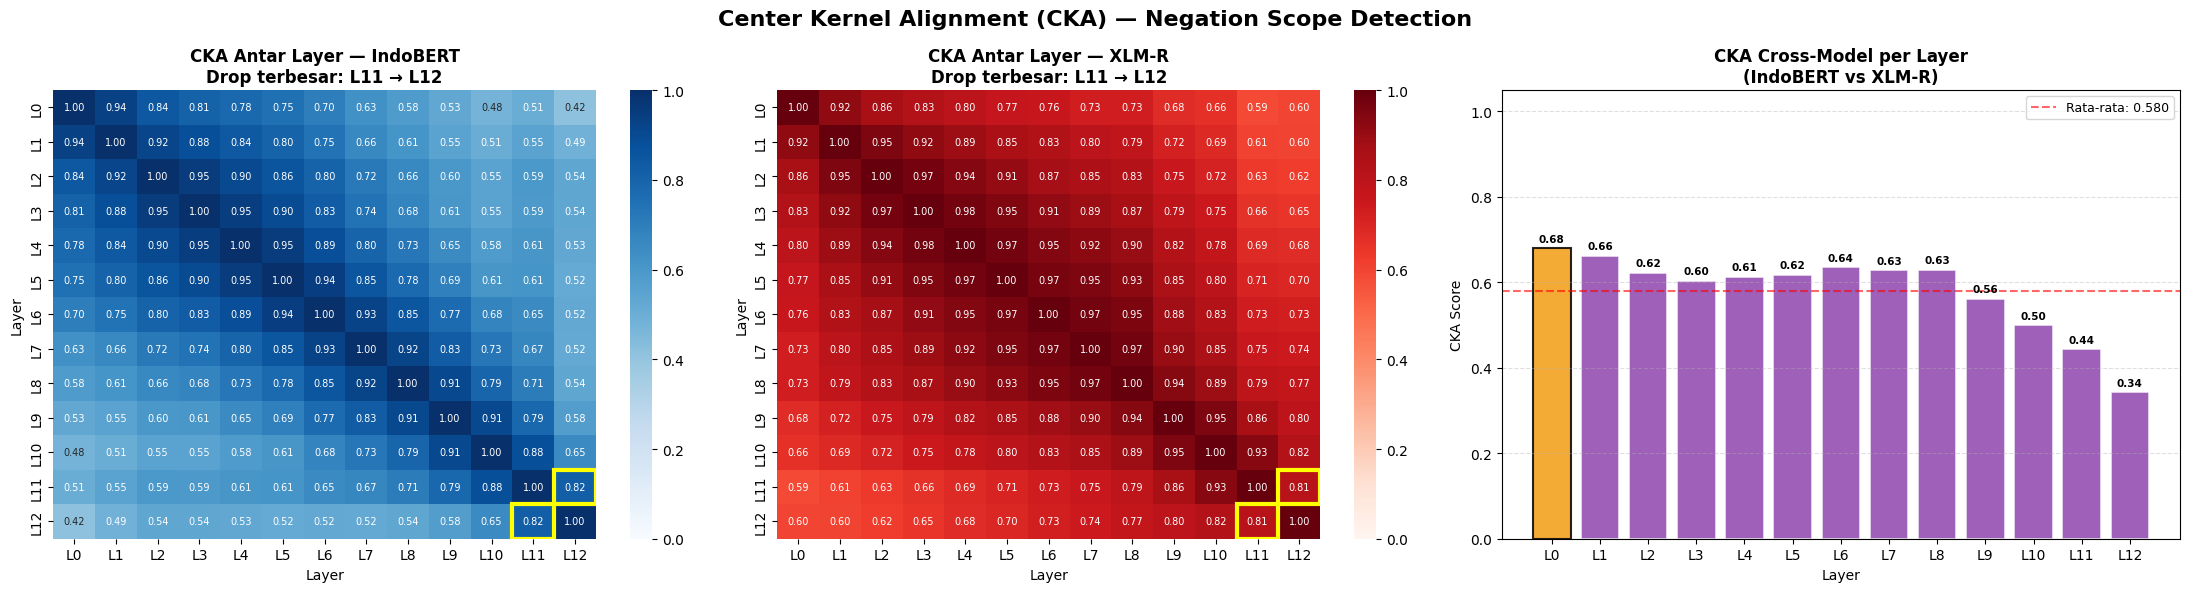

In [20]:
# ============================================================
# TAHAP 7: CENTER KERNEL ALIGNMENT (CKA) — NEGATION SCOPE
# ============================================================

# ------------------------------------------------------------
# 1) Fungsi CKA
# ------------------------------------------------------------

def centering(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_cka(X, Y):
    K = centering(X @ X.T)
    L = centering(Y @ Y.T)
    num = np.sum(K * L)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(L * L))
    return float(num / den) if den > 0 else 0.0

def compute_cka_matrix(X_layers):
    n = X_layers.shape[1]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = linear_cka(X_layers[:, i, :], X_layers[:, j, :])
    return M

# ------------------------------------------------------------
# 2) SAMPLING DATA
# ------------------------------------------------------------

MAX_CKA = 1000
n_test  = X_neg_test_ib.shape[0]

np.random.seed(42)
idx_cka = np.random.choice(n_test, size=min(MAX_CKA, n_test), replace=False)

X_cka_ib  = X_neg_test_ib [idx_cka]   # (MAX_CKA, 13, 768)
X_cka_xlm = X_neg_test_xlm[idx_cka]

print(f"✅ Data CKA siap dengan shape: {X_cka_ib.shape}")

# ------------------------------------------------------------
# 3) HITUNG CKA
# ------------------------------------------------------------

print("Menghitung CKA internal IndoBERT...")
cka_neg_ib    = compute_cka_matrix(X_cka_ib)

print("Menghitung CKA internal XLM-R...")
cka_neg_xlm   = compute_cka_matrix(X_cka_xlm)

print("Menghitung CKA cross-model per layer...")
cka_neg_cross = np.array([
    linear_cka(X_cka_ib[:, i, :], X_cka_xlm[:, i, :])
    for i in range(NUM_LAYERS)
])

# ------------------------------------------------------------
# 4) VISUALISASI
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Center Kernel Alignment (CKA) — Negation Scope Detection',
             fontsize=16, fontweight='bold')

# ── Heatmap IndoBERT ────────────────────────────────────────
sns.heatmap(
    cka_neg_ib,
    ax=axes[0],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_ib_idx, seq_cka_ib, seq_drop_ib = highlight_sequential_max(axes[0], cka_neg_ib)

axes[0].set_title(
    f'CKA Antar Layer — IndoBERT\nDrop terbesar: L{best_ib_idx} → L{best_ib_idx+1}',
    fontweight='bold'
)
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')

# ── Heatmap XLM-R ───────────────────────────────────────────
sns.heatmap(
    cka_neg_xlm,
    ax=axes[1],
    xticklabels=layer_ticks,
    yticklabels=layer_ticks,
    vmin=0, vmax=1,
    cmap='Reds',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)

best_xlm_idx, seq_cka_xlm, seq_drop_xlm = highlight_sequential_max(axes[1], cka_neg_xlm)

axes[1].set_title(
    f'CKA Antar Layer — XLM-R\nDrop terbesar: L{best_xlm_idx} → L{best_xlm_idx+1}',
    fontweight='bold'
)
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')

# ── Cross-model Bar Chart ───────────────────────────────────
bars = axes[2].bar(
    layer_ticks,
    cka_neg_cross,
    color='#8e44ad',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

best_cross_neg = int(np.argmax(cka_neg_cross))

bars[best_cross_neg].set_color('#f39c12')
bars[best_cross_neg].set_edgecolor('black')
bars[best_cross_neg].set_linewidth(1.5)

axes[2].set_title('CKA Cross-Model per Layer\n(IndoBERT vs XLM-R)',
                  fontweight='bold')
axes[2].set_xlabel('Layer')
axes[2].set_ylabel('CKA Score')
axes[2].set_ylim(0, 1.05)

axes[2].axhline(
    y=np.mean(cka_neg_cross),
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Rata-rata: {np.mean(cka_neg_cross):.3f}'
)

axes[2].legend(fontsize=9)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

for i, val in enumerate(cka_neg_cross):
    axes[2].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.show()